# 실험의 전제와 목표

1. **전제** 
    - ImageNet으로 사전학습된 세 모델 ResNet, DenseNet, EfficientNet 각각을 전이학습한다. 
    - 전이학습 방법으로는 Feature Extraction, Partial Fine-Tuning, Full Fine-Tuning을 진행한다. 
    - 이미지 전처리 전략으로는 4 가지를 둔다.
    - 학습은 무료 구독 colab GPU T4에서 진행한다. 
    - 로컬 환경은 mps.

2. **목표**
    - 폐렴 예측 과제를 가장 잘 수행하는 **모델 x 전이학습 조합**을 확인한다. 
    - 그 조합에서 사용된 **데이터셋 전처리 전략**은 무엇이었는 지 확인한다. 
    - 결과에 대해 **설명**할 수 있다. 

- **실험 대상 모델**

    | 모델 | 첫 conv | head | Partial에서 푸는 마지막 stage |
    |--|--|--|--|
    | resnet50 | conv1 | fc (2048) | layer4 |
    | densenet121 | features.conv0 | classifier (1024) | features.denseblock4, features.norm5 |
    | efficientnet_b0 | features.0.0 | classifier.1 (1280, 앞 Dropout 유지) | features.7, features.8(마지막 1×1 conv) |

- **실험 대상 전이학습 방법**
    | 학습 방법 | 정의 | 
    | -- | -- |
    | Feature Extraction(Frozen) | 특징 추출기 부분은 완전히 고정하고, 분류기 부분만 ImageNet 가중치 위에서 fine-tuning한다. 
    | Paritial Fine-Tuning | 특징 추출기의 마지막 stage 하나와 분류기 head를 제외한 부분은 freeze. ImageNet 사전학습 가중치 위에서 재학습한다. |
    | Full Fine-Tuning | 모든 가중치를 ImageNet 사전학습 가중치 위에서 Fine-Tuning 한다. | 

- **실험 대상 데이터 전처리 방법** 
    | 전처리 방법 | Channel | Sizing | Equalization | Augmentation | Normalization | 
    | -- | -- | -- | -- | -- | -- |
    | pad__none | 3채널 | 비율 유지 패딩 | CLAHE X | rotation + Hflip | ImageNet 통계 기준 |
    | pad__clahe | 3채널 | 비율 유지 패딩 | CLAHE O | rotation + Hflip | ImageNet 통계 기준 |
    | squash__none | 3채널 | 224×224 직접 리사이즈(squash, 종횡비 무시) | CLAHE X | rotation + Hflip | ImageNet 통계 기준 |
    | squash__clahe | 3채널 | 224×224 직접 리사이즈(squash, 종횡비 무시) | CLAHE O | rotation + Hflip | ImageNet 통계 기준 |

---
- ***여유가 되면 추가***: 
    - 사전학습된 U-Net을 정상 폐, 폐렴 폐, 또는 갈비뼈 이미지로 전이학습해 폐 bbox를 추출하도록 학습시킨다.
    - 추출된 bbox 기준 여유 padding을 줘서 갈비뼈 부분만 crop할 수 있도록 한다. 
    - bbox 추출 모델을 활용한 이미지 전처리를 적용했을 때 성능이 얼마나 바뀌는지 실험으로 확인한다. 
    - 10/1 이 U-Net 이용 crop 방식을 EDA는 했으나 실험이 넣지 않은 이유: UNet을 사용한 bbox 검출 crop 방식은 이에 작용할 수 있는 변수가 너무 많다.UNet을 전이학습한 데이터셋의 퀄리티와 그 학습 방법 퀄리티가 본 실험 대상 데이터셋 퀄리티에 너무 큰 영향을 준다. 따라서 UNet을 이용한 데이터 전처리는 데이터셋의 차이로 비교되지 않고, UNet의 성능의 차이로 비교될 여지가 있다는 게 가장 큰 우려다. 
    - 자체적인 폐/갈비뼈 bbox 추론 모델을 안정적으로 구축하기 전까지는 이 실험이 의미가 없다. 

# 0. 공통 실험 인프라 구축
- 상수 모음
- 시드 고정
- colab(cuda)/로컬(mps) 디바이스 설정
- colab/로컬 환경 data/result 드라이브 마운트/경로 설정
- 평가 함수(Accuracy, Precision, Recall, F1, confusion matrix, ROC-AUC)
- best-eval checkpoint 저장이 포함된 train/evaluate 함수

In [1]:
# ---------- import ----------
import copy
import hashlib
import os
import random
import re
import sys
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_recall_fscore_support,
                             roc_auc_score)
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import WeightedRandomSampler

# ---------- 상수 ----------
SEED = 42
IMG_SIZE = 224
SPLITS = ["train", "val", "test"]
CLASSES = ["NORMAL", "PNEUMONIA"]          # label index: NORMAL=0, PNEUMONIA=1(positive)
POS_LABEL = 1

# 정규화: 흑백을 3채널로 복제한 뒤 ImageNet 채널별 통계로 정규화한다
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# 데이터 분할 / 전처리 / 증강
VAL_RATIO = 0.1                    # train+val : test ≈ 9:1 이므로 train:val도 9:1
CLAHE_CLIP, CLAHE_TILE = 2.0, (8, 8)  # EDA 3-5와 동일
ROT_DEG = 10                       # 랜덤 회전 범위(±deg)
HFLIP_P = 0.5

BATCH_SIZE = 32

In [2]:
# ---------- 시드 고정 ----------
def seed_everything(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

In [3]:
# ---------- 디바이스: colab(cuda) / 로컬(mps) ----------
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

# ---------- 경로: colab은 Drive 마운트, 로컬은 현재 폴더 ----------
IN_COLAB = "google.colab" in sys.modules
DRIVE_PROJECT = "CodeIT/Colab/mission6_xray"  # MyDrive 아래 프로젝트 폴더명

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive") / DRIVE_PROJECT
else:
    PROJECT_DIR = Path(".")

DATA_DIR = PROJECT_DIR / "data"
RESULT_DIR = PROJECT_DIR / "results"
CACHE_DIR = RESULT_DIR / "cache"            # 전처리 캐시(npz)
CKPT_DIR = RESULT_DIR / "checkpoints"       # best-eval / 재개용 checkpoint
TB_DIR = RESULT_DIR / "runs"                # TensorBoard 로그
HIST_DIR = RESULT_DIR / "history"           # run별 에폭 기록 CSV
for d in (CACHE_DIR, CKPT_DIR, TB_DIR, HIST_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), f"데이터 폴더가 없습니다: {DATA_DIR.resolve()}"
print(f"device={DEVICE}, colab={IN_COLAB}")
print(f"DATA_DIR={DATA_DIR.resolve()}\nRESULT_DIR={RESULT_DIR.resolve()}")

Mounted at /content/drive
device=cuda, colab=True
DATA_DIR=/content/drive/MyDrive/CodeIT/Colab/mission6_xray/data
RESULT_DIR=/content/drive/MyDrive/CodeIT/Colab/mission6_xray/results


In [4]:
# ---------- 평가 함수 ----------
def compute_metrics(y_true, y_prob, threshold: float = 0.5) -> dict:
    """PNEUMONIA(=1)를 positive로 보고 Accuracy / Precision / Recall / F1 / ROC-AUC / confusion matrix를 계산한다."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=POS_LABEL, zero_division=0)
    # 한 클래스만 있는 배치/부분집합에서는 AUC가 정의되지 않는다
    roc_auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else float("nan")
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[0, 1]),
    }


def plot_confusion_matrix(cm, title: str = "", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(3.6, 3.2))
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1], CLASSES)
    ax.set_yticks([0, 1], CLASSES)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    return ax

In [5]:
# ---------- TensorBoard (colab은 기본 설치, 로컬은 pip install tensorboard) ----------
try:
    from torch.utils.tensorboard import SummaryWriter
except ImportError:
    SummaryWriter = None
    print("tensorboard 미설치: 학습 기록은 history DataFrame/CSV에만 남습니다.")


def make_writer(run_name: str, purge_step: int | None = None):
    """purge_step: 재개 시 이 step 이후의 기존 기록(끊긴 세션에서 남은 중복)을 지운다."""
    return SummaryWriter(log_dir=str(TB_DIR / run_name), purge_step=purge_step) if SummaryWriter else None


# ---------- train / evaluate ----------
# 모델은 2-class logits (B, 2)를 출력한다고 가정한다. loader는 (x, y)를 device 위 텐서로 준다.
def set_frozen_eval(model):
    """학습 가능한 파라미터가 하나도 없는 서브모듈(동결된 stage)은 eval로 둔다.
    Frozen/Partial에서 동결 부분의 BN running stats와 StochasticDepth까지 사전학습 상태 그대로 고정하기 위함 (full이면 no-op)."""
    for m in model.modules():
        params = list(m.parameters())
        if params and not any(p.requires_grad for p in params):
            m.eval()


def train_one_epoch(model, loader, criterion, optimizer, device=DEVICE):
    model.train()
    set_frozen_eval(model)
    total_loss, n_correct, n = 0.0, 0, 0
    conf = torch.zeros(3, dtype=torch.long, device=device)   # PNEUMONIA(=1) 기준 tp / fp / fn (device에서 누적해 동기화를 늘리지 않는다)
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        pred = logits.argmax(1)
        n_correct += (pred == y).sum().item()
        pos_pred, pos_true = pred == POS_LABEL, y == POS_LABEL
        conf += torch.stack([(pos_pred & pos_true).sum(), (pos_pred & ~pos_true).sum(), (~pos_pred & pos_true).sum()])
        n += y.size(0)
    tp, fp, fn = conf.tolist()
    return {"loss": total_loss / n, "accuracy": n_correct / n,
            "recall": tp / (tp + fn) if tp + fn else 0.0, "f1": 2 * tp / (2 * tp + fp + fn) if tp else 0.0}


@torch.no_grad()
def evaluate(model, loader, criterion, device=DEVICE, threshold: float = 0.5):
    """loss + compute_metrics 결과와, 사후 분석용 y_true / y_prob(PNEUMONIA 확률)를 함께 반환한다."""
    model.eval()
    total_loss, n = 0.0, 0
    y_true, y_prob = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        total_loss += criterion(logits, y).item() * y.size(0)
        n += y.size(0)
        y_true.append(y.cpu())
        y_prob.append(logits.softmax(1)[:, POS_LABEL].cpu())
    y_true = torch.cat(y_true).numpy()
    y_prob = torch.cat(y_prob).numpy()
    metrics = {"loss": total_loss / n, **compute_metrics(y_true, y_prob, threshold)}
    return metrics, y_true, y_prob


# ---------- checkpoint: best(가중치) / last(재개용 전체 상태) ----------
def _atomic_save(obj, path: Path):
    """임시 파일에 쓴 뒤 교체한다. 저장 도중 세션이 끊겨도 기존 파일이 깨지지 않는다."""
    tmp = path.with_name(path.name + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)


def _get_rng_state(train_loader) -> dict:
    state = {"python": random.getstate(), "numpy": np.random.get_state(), "torch": torch.get_rng_state()}
    if torch.cuda.is_available():
        state["cuda"] = torch.cuda.get_rng_state_all()
    elif torch.backends.mps.is_available():
        state["mps"] = torch.mps.get_rng_state()
    if hasattr(train_loader, "rng_state"):
        state["loader"] = train_loader.rng_state()
    return state


def _set_rng_state(state: dict, train_loader):
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch"])
    if "cuda" in state and torch.cuda.is_available():
        torch.cuda.set_rng_state_all(state["cuda"])
    if "mps" in state and torch.backends.mps.is_available():
        torch.mps.set_rng_state(state["mps"])
    if "loader" in state and hasattr(train_loader, "load_rng_state"):
        train_loader.load_rng_state(state["loader"])


def fit(model, train_loader, val_loader, criterion, optimizer, epochs: int, run_name: str,
        scheduler=None, monitor: str = "f1", tensorboard: bool = True, save_every: int = 3,
        resume: bool = True, device=DEVICE, ckpt_dir: Path = CKPT_DIR, hist_dir: Path = HIST_DIR):
    """매 에폭 train/val 지표를 모두 기록하고, val `monitor` 지표가 가장 좋은 에폭의 가중치를 `{run}_best.pt`로 저장한다.
    `save_every` 에폭마다(+마지막 에폭) 재개용 `{run}_last.pt`와 `history/{run}.csv`를 덮어쓰고,
    resume=True면 `{run}_last.pt`에서 이어서 학습한다. 끝나면 best 가중치를 모델에 로드하고 history를 반환한다.
    monitor: "f1" | "recall" | "roc_auc" | "precision" | "accuracy" | "loss"(loss만 최소화)
    optimizer param group에 "name"("head"/"backbone")이 있으면 그룹별 lr을 기록한다.
    ckpt_dir / hist_dir: checkpoint / history 저장 폴더 (5장 K-Fold는 results/kfold/ 아래로 분리한다)
    """
    model.to(device)
    minimize = monitor == "loss"
    best_path = ckpt_dir / f"{run_name}_best.pt"
    last_path = ckpt_dir / f"{run_name}_last.pt"
    hist_path = hist_dir / f"{run_name}.csv"
    history, best_state, best_epoch, best_val_metrics = [], None, -1, None
    best_score = float("inf") if minimize else -float("inf")
    start_epoch = 1

    if resume and last_path.exists():
        ck = torch.load(last_path, map_location="cpu", weights_only=False)
        model.load_state_dict(ck["model"])
        optimizer.load_state_dict(ck["optimizer"])
        if scheduler is not None and ck["scheduler"] is not None:
            scheduler.load_state_dict(ck["scheduler"])
        history, best_state = ck["history"], ck["best_state"]
        best_score, best_epoch, best_val_metrics = ck["best_score"], ck["best_epoch"], ck["best_val_metrics"]
        _set_rng_state(ck["rng"], train_loader)
        start_epoch = ck["epoch"] + 1
        # 끊긴 세션이 last 이후에 best를 갱신했을 수 있으므로 last 시점의 best로 되돌린다
        _atomic_save({"state_dict": best_state, "epoch": best_epoch, "monitor": monitor,
                      "val_metrics": best_val_metrics}, best_path)
        print(f"[{run_name}] resume from epoch {ck['epoch']} (best epoch={best_epoch})")

    writer = make_writer(run_name, purge_step=start_epoch) if tensorboard else None
    for epoch in range(start_epoch, epochs + 1):
        t0 = time.time()
        lrs = {g.get("name", f"group{i}"): g["lr"] for i, g in enumerate(optimizer.param_groups)}
        tr = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va, _, _ = evaluate(model, val_loader, criterion, device)
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(va["loss"])
            else:
                scheduler.step()

        score = va[monitor]
        # 첫 에폭은 항상 저장한다 (monitor가 NaN이어도 best 가중치가 비지 않도록)
        improved = best_state is None or (score < best_score if minimize else score > best_score)
        val_scalars = {k: v for k, v in va.items() if k != "confusion_matrix"}
        if improved:
            best_score, best_epoch, best_val_metrics = score, epoch, val_scalars
            best_state = copy.deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
            _atomic_save({"state_dict": best_state, "epoch": epoch, "monitor": monitor,
                          "val_metrics": val_scalars}, best_path)

        tn, fp, fn, tp = va["confusion_matrix"].ravel().tolist()
        row = {"epoch": epoch,
               "lr_head": lrs.get("head", next(iter(lrs.values()))), "lr_backbone": lrs.get("backbone", float("nan")),
               "train_loss": tr["loss"], "train_accuracy": tr["accuracy"],
               "train_recall": tr["recall"], "train_f1": tr["f1"],
               **{f"val_{k}": v for k, v in val_scalars.items()},
               "val_tn": tn, "val_fp": fp, "val_fn": fn, "val_tp": tp,
               "is_best": improved, "sec": time.time() - t0}
        history.append(row)

        if writer is not None:
            writer.add_scalars("loss", {"train": tr["loss"], "val": va["loss"]}, epoch)
            writer.add_scalars("accuracy", {"train": tr["accuracy"], "val": va["accuracy"]}, epoch)
            for k in ("precision", "recall", "f1", "roc_auc"):
                writer.add_scalar(f"val/{k}", va[k], epoch)
            writer.add_scalars("lr", {k: v for k, v in lrs.items()}, epoch)

        if epoch % save_every == 0 or epoch == epochs:
            pd.DataFrame(history).to_csv(hist_path, index=False)
            _atomic_save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                          "scheduler": scheduler.state_dict() if scheduler is not None else None,
                          "epoch": epoch, "history": history,
                          "best_state": best_state, "best_score": best_score, "best_epoch": best_epoch,
                          "best_val_metrics": best_val_metrics, "rng": _get_rng_state(train_loader)}, last_path)

        print(f"[{run_name}] ep {epoch:02d} | train loss {tr['loss']:.4f} acc {tr['accuracy']:.3f} | "
              f"val loss {va['loss']:.4f} acc {va['accuracy']:.3f} rec {va['recall']:.3f} "
              f"f1 {va['f1']:.3f} auc {va['roc_auc']:.3f} | {row['sec']:.0f}s" + (" *" if improved else ""))

    if writer is not None:
        writer.close()
    model.load_state_dict(best_state)
    print(f"[{run_name}] best epoch={best_epoch} ({monitor}={best_score:.4f}) -> {best_path}")
    return pd.DataFrame(history)

# 1. 데이터 전처리
- **데이터 재분할:**
    - train+val 합친 후 split한다. 
    - person id 그룹 기준으로 나눈다. 동일 id가 train/val에 섞여들어가지 않도록 한다. 
- **test 해시 기준 중복 이미지 제거**
    - EDA에서 확인한 중복 이미지 6장에서 한 장만 남기고 제거한다. 
- **소수 클래스(NORMAL) 가중치**
    - WeightedRandomSampler를 활용한다. 
- **전처리 데이터셋 변형 정의:**
    - 고정할 것:
        - Normalization: ImageNet 통계 기준으로 정규화한다. 
            - 근거: 전이학습 대상 데이터와 ImageNet 통계 데이터 기준 정규화 간에 차이가 거의 없었다. 따라서 사전학습 가중치에 맞는 정규화 방식을 사용하는 것으로 한다. 
        - data channel: 3채널로 고정한다. 
            - 근거: 사전학습 첫번째 conv 레이어가 3채널을 받도록 설계되어있다. 그리고 따라서 1채널을 넣으려면 첫 번쨰 conv 레이어를 1채널을 받도록 수정해서 넣어야 하고, 이 때 가중치는 W_R * g + W_G * g + W_B * g  =  (W_R + W_G + W_B) * g 이 공식을 써서 합산해서 1채널 필터로 만든다. 즉 3채널에 같은 이미지를 넣는 것과, RGB가중치를 더한 1채널 필터에 한 번에 넣는 것은 같은 계산이다. 1ch VS 3ch 비교는 사실상 같은 모델을 두 번 돌리는 것에 가깝다. 
        - Augmentation: 데이터 증강은 안정적인 Rotation + Hflip으로 진행한다. 과적합을 방지하는 데에 도움을 줌이 저번 실험으로 증명되었기 때문이다. 

    - 변수로 처리할 것:
        - **CLAHE: 적용 vs 미적용**
            - 목표: CLAHE로 국소부위 콘트라스트를 올리는 게 성능에 영향을 주는 지 확인한다. 
        - **Sizing: 비율 유지 패딩(224,224) vs squash(224,224)**
            - 목표: EDA에서 수립한 가설인, "클래스 별로 이미지 크기와 종횡비 차이가 구분되기 때문에 이것이 성능에 영향을 줄것이다"라는 가설이 성립하는 지 확인한다. 
            - 우려: test 세트도 종횡비 차이가 나기 때문에 현재 갖고있는 데이터들로는 아주 객관적으로 확인하기 힘들것이라는 게 우려사항이다. 

- **실험 대상 데이터 전처리 방법**
    | 전처리 방법 | Channel | Sizing | Equalization | Augmentation | Normalization | 
    | -- | -- | -- | -- | -- | -- |
    | pad__none | 3채널 | 비율 유지 패딩 | CLAHE X | rotation + Hflip | ImageNet 통계 기준 |
    | pad__clahe | 3채널 | 비율 유지 패딩 | CLAHE O | rotation + Hflip | ImageNet 통계 기준 |
    | squash__none | 3채널 | 224×224 직접 리사이즈(squash, 종횡비 무시) | CLAHE X | rotation + Hflip | ImageNet 통계 기준 |
    | squash__clahe | 3채널 | 224×224 직접 리사이즈(squash, 종횡비 무시) | CLAHE O | rotation + Hflip | ImageNet 통계 기준 |

In [6]:
# ---------- 메타 수집: 경로 / 라벨 / 환자 그룹 / (test) 픽셀 해시 ----------
PERSON_RE = re.compile(r"person(\d+)_(bacteria|virus)_(\d+)")
NORMAL_RE = re.compile(r"^(.*IM-\d+)-")   # NORMAL은 person id 대신 'IM-0523' 같은 접두가 환자 번호 역할을 한다


def group_key(cls: str, filename: str) -> str:
    m = PERSON_RE.match(filename) if cls == "PNEUMONIA" else NORMAL_RE.match(filename)
    return f"{cls}/{m.group(1)}" if m else f"{cls}/{filename}"   # 매칭 실패 시 단독 그룹


def pixel_md5(path) -> str:
    with Image.open(path) as im:
        return hashlib.md5(np.asarray(im.convert("L")).tobytes()).hexdigest()


def build_meta() -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        for label, cls in enumerate(CLASSES):
            for p in sorted((DATA_DIR / split / cls).glob("*.jpeg")):
                rows.append({"rel_path": f"{split}/{cls}/{p.name}", "orig_split": split, "cls": cls,
                             "label": label, "group": group_key(cls, p.name)})
    meta = pd.DataFrame(rows)
    # 픽셀 해시는 test 중복 제거에만 필요하다 (EDA 5-1과 같은 convert("L") 기준)
    is_test = meta["orig_split"] == "test"
    meta.loc[is_test, "pixel_md5"] = [pixel_md5(DATA_DIR / r) for r in meta.loc[is_test, "rel_path"]]
    return meta


meta = build_meta()
display(pd.crosstab(meta["orig_split"], meta["cls"]).reindex(SPLITS))

cls,NORMAL,PNEUMONIA
orig_split,,
train,1341,3875
val,8,8
test,234,390


In [7]:
# ---------- 데이터 재분할: train+val을 합친 뒤 환자 그룹 단위로 9:1 층화 분할 ----------
pool = meta[meta["orig_split"] != "test"].reset_index(drop=True)
sgkf = StratifiedGroupKFold(n_splits=round(1 / VAL_RATIO), shuffle=True, random_state=SEED)
tr_idx, va_idx = next(sgkf.split(pool, pool["label"], groups=pool["group"]))
train_df = pool.iloc[tr_idx].reset_index(drop=True)
val_df = pool.iloc[va_idx].reset_index(drop=True)

leak = set(train_df["group"]) & set(val_df["group"])
assert not leak, f"train/val에 같은 그룹이 섞였습니다: {list(leak)[:5]}"

ct = pd.DataFrame({name: df["cls"].value_counts().reindex(CLASSES)
                   for name, df in [("train", train_df), ("val", val_df)]}).T
display(pd.concat({"count": ct, "ratio": ct.div(ct.sum(axis=1), axis=0).round(3)}, axis=1)
        .assign(total=ct.sum(axis=1), groups=[train_df["group"].nunique(), val_df["group"].nunique()]))

count            ratio           total groups
cls   NORMAL PNEUMONIA NORMAL PNEUMONIA             
train   1211      3514  0.256     0.744  4725   2577
val      138       369  0.272     0.728   507    284

In [8]:
# ---------- test 해시 기준 중복 이미지 제거: 중복 그룹마다 첫 장만 남긴다 ----------
test_all = meta[meta["orig_split"] == "test"]
dup_mask = test_all.duplicated("pixel_md5", keep="first")
print(f"test: {len(test_all)} -> {len(test_all) - dup_mask.sum()} (중복 {dup_mask.sum()}장 제거)")
display(test_all[test_all.duplicated("pixel_md5", keep=False)]
        .assign(removed=dup_mask)[["rel_path", "cls", "pixel_md5", "removed"]])
test_df = test_all[~dup_mask].reset_index(drop=True)

test: 624 -> 618 (중복 6장 제거)


,rel_path,cls,pixel_md5,removed
5326,test/NORMAL/NORMAL2-IM-0095-0001.jpeg,NORMAL,490238debf98e38314601339655f5d7a,False
5327,test/NORMAL/NORMAL2-IM-0096-0001.jpeg,NORMAL,490238debf98e38314601339655f5d7a,True
5349,test/NORMAL/NORMAL2-IM-0173-0001-0001.jpeg,NORMAL,bcd47182e622a00b47ca8a483736af8c,False
5350,test/NORMAL/NORMAL2-IM-0173-0001-0002.jpeg,NORMAL,bcd47182e622a00b47ca8a483736af8c,True
5370,test/NORMAL/NORMAL2-IM-0246-0001-0001.jpeg,NORMAL,46c9cc352433b6d00234274328e74334,False
5371,test/NORMAL/NORMAL2-IM-0246-0001-0002.jpeg,NORMAL,46c9cc352433b6d00234274328e74334,True
5551,test/PNEUMONIA/person128_bacteria_606.jpeg,PNEUMONIA,2f340970400a806e8a5ee314a48aaf27,False
5552,test/PNEUMONIA/person128_bacteria_607.jpeg,PNEUMONIA,2f340970400a806e8a5ee314a48aaf27,True
5569,test/PNEUMONIA/person134_bacteria_643.jpeg,PNEUMONIA,a285a7d87f39959bf7567703a3b1bab4,False
5570,test/PNEUMONIA/person134_bacteria_644.jpeg,PNEUMONIA,a285a7d87f39959bf7567703a3b1bab4,True


In [9]:
# ---------- 전처리 (a) 결정적 단계를 1회만 계산해 캐시 ----------
# 흑백 변환 -> (CLAHE: 원본 해상도에서 적용) -> sizing(pad / squash) 224.
# 매 에폭 같은 결과가 나오는 단계라 JPEG 디코딩/CLAHE/resize 비용을 학습 루프에서 제거한다.
# pad와 squash는 같은 보간(PIL BILINEAR)을 쓰고, 종횡비를 지키는지만 다르다.
VARIANTS = {  # name: (sizing, clahe)
    "pad__none": ("pad", False),
    "pad__clahe": ("pad", True),
    "squash__none": ("squash", False),
    "squash__clahe": ("squash", True),
}


def resize_pad(gray: np.ndarray, size: int = IMG_SIZE) -> np.ndarray:
    """긴 변을 size에 맞추고 남는 영역을 0(검정)으로 채운다. EDA 3-6의 resize_pad와 같다."""
    im = Image.fromarray(gray)
    w, h = im.size
    s = size / max(w, h)
    im = im.resize((max(1, round(w * s)), max(1, round(h * s))), Image.BILINEAR)
    canvas = Image.new("L", (size, size), 0)
    canvas.paste(im, ((size - im.width) // 2, (size - im.height) // 2))
    return np.asarray(canvas)


def resize_squash(gray: np.ndarray, size: int = IMG_SIZE) -> np.ndarray:
    """종횡비를 무시하고 size x size로 바로 리사이즈한다(패딩 없음)."""
    return np.asarray(Image.fromarray(gray).resize((size, size), Image.BILINEAR))


SIZERS = {"pad": resize_pad, "squash": resize_squash}


def _preprocess_one(rel_path: str) -> dict:
    with Image.open(DATA_DIR / rel_path) as im:
        gray = np.asarray(im.convert("L"))
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)  # 스레드마다 별도 객체
    eq = {False: gray, True: clahe.apply(gray)}
    return {name: SIZERS[sizing](eq[use_clahe]) for name, (sizing, use_clahe) in VARIANTS.items()}


def load_or_build_cache(rel_paths, force: bool = False) -> dict:
    """{variant: uint8 (N,224,224)}. 순서는 rel_paths와 같다."""
    path = CACHE_DIR / f"preprocessed_v2_{IMG_SIZE}.npz"
    rel_paths = np.asarray(rel_paths)
    if path.exists() and not force:
        z = np.load(path)
        if np.array_equal(z["rel_paths"], rel_paths) and all(k in z for k in VARIANTS):
            return {k: z[k] for k in VARIANTS}
        print("캐시의 이미지 목록/변형이 달라 다시 만듭니다.")

    t0 = time.time()
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:   # PIL 디코딩/cv2는 GIL을 놓아서 스레드로 병렬화된다
        out = list(ex.map(_preprocess_one, rel_paths, chunksize=32))
    cache = {k: np.stack([o[k] for o in out]) for k in VARIANTS}
    np.savez(path, rel_paths=rel_paths, **cache)
    print(f"캐시 생성: {len(rel_paths)}장, {time.time() - t0:.0f}s -> {path}")
    return cache


# train / val / test 전체를 한 배열에 담고, 각 split은 인덱스로 가리킨다
all_df = pd.concat([train_df.assign(split="train"), val_df.assign(split="val"), test_df.assign(split="test")],
                   ignore_index=True)
CACHE = load_or_build_cache(sorted(all_df["rel_path"]))
_pos = {p: i for i, p in enumerate(sorted(all_df["rel_path"]))}
all_df["cache_idx"] = all_df["rel_path"].map(_pos)
print({k: (v.shape, v.dtype, f"{v.nbytes / 1e6:.0f}MB") for k, v in CACHE.items()})

{'pad__none': ((5850, 224, 224), dtype('uint8'), '294MB'), 'pad__clahe': ((5850, 224, 224), dtype('uint8'), '294MB'), 'squash__none': ((5850, 224, 224), dtype('uint8'), '294MB'), 'squash__clahe': ((5850, 224, 224), dtype('uint8'), '294MB')}


In [10]:
# ---------- 전처리 (b) 데이터 GPU 상주 + (c) 배치 단위 GPU 증강/정규화 ----------
# 모든 모델 x 전이학습 방법 x 전처리 변형이 같은 캐시 -> 같은 증강 -> 같은 sampler를 탄다.
# sampler / 증강 난수는 run마다 시드 고정된 전용 Generator(CPU)에서 뽑는다.
# 같은 시드면 모든 변형이 같은 샘플 순서와 같은 증강 파라미터를 받고, 이미지의 전처리만 다르다.
_DEVICE_IMAGES = {}   # 현재 변형 하나만 device에 둔다 (그리드는 변형 순으로 돌아 교체가 적다)


def device_images(variant: str) -> torch.Tensor:
    if variant not in _DEVICE_IMAGES:
        _DEVICE_IMAGES.clear()
        _DEVICE_IMAGES[variant] = torch.from_numpy(CACHE[variant]).unsqueeze(1).to(DEVICE)  # uint8 (N,1,H,W)
    return _DEVICE_IMAGES[variant]


class GpuTransform:
    """uint8 (B,1,H,W) -> 3채널 복제 + ImageNet 정규화 텐서 (B,3,H,W).
    train이면 샘플별 회전(±ROT_DEG) + 좌우반전을 한 번의 affine으로 적용한다."""

    def __init__(self, train: bool, generator: torch.Generator | None = None):
        self.train, self.gen = train, generator
        self.mean = torch.tensor(IMAGENET_MEAN, device=DEVICE).view(1, -1, 1, 1)
        self.std = torch.tensor(IMAGENET_STD, device=DEVICE).view(1, -1, 1, 1)

    def augment(self, x):
        b = x.size(0)
        # 배치 전체가 아니라 샘플마다 각도/반전을 따로 뽑는다
        angle = (torch.rand(b, generator=self.gen) * 2 - 1) * np.deg2rad(ROT_DEG)
        flip = torch.where(torch.rand(b, generator=self.gen) < HFLIP_P, -1.0, 1.0)
        cos, sin = torch.cos(angle), torch.sin(angle)
        theta = torch.zeros(b, 2, 3)
        theta[:, 0, 0], theta[:, 0, 1] = cos * flip, -sin
        theta[:, 1, 0], theta[:, 1, 1] = sin * flip, cos
        grid = F.affine_grid(theta.to(x.device), list(x.shape), align_corners=False)
        return F.grid_sample(x, grid, mode="bilinear", padding_mode="zeros", align_corners=False)  # 바깥은 배경 0

    def __call__(self, x_uint8):
        x = x_uint8.float().div_(255)
        if self.train:
            x = self.augment(x)
        return (x.expand(-1, 3, -1, -1) - self.mean) / self.std


class GpuBatchLoader:
    """device에 올라간 이미지 텐서에서 인덱스로 배치를 꺼낸다. DataLoader의 워커/collate/전송 비용이 없다."""

    def __init__(self, images, indices, labels, transform, batch_size=BATCH_SIZE, sampler=None):
        self.images = images
        self.indices = torch.tensor(indices, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.labels_dev = self.labels.to(DEVICE)
        self.transform, self.batch_size, self.sampler = transform, batch_size, sampler

    def __len__(self):
        n = len(self.sampler) if self.sampler is not None else len(self.indices)
        return (n + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        order = (torch.as_tensor(list(self.sampler), dtype=torch.long) if self.sampler is not None
                 else torch.arange(len(self.indices)))
        for s in range(0, len(order), self.batch_size):
            pos = order[s:s + self.batch_size]
            x = self.images[self.indices[pos].to(DEVICE)]
            yield self.transform(x), self.labels_dev[pos.to(DEVICE)]

    def rng_state(self) -> dict:
        """재개용: sampler / 증강 Generator 상태."""
        gens = {"sampler": getattr(self.sampler, "generator", None), "augment": self.transform.gen}
        return {k: g.get_state() for k, g in gens.items() if g is not None}

    def load_rng_state(self, state: dict):
        gens = {"sampler": getattr(self.sampler, "generator", None), "augment": self.transform.gen}
        for k, g in gens.items():
            if g is not None and k in state:
                g.set_state(state[k])


def make_loaders(variant: str, batch_size: int = BATCH_SIZE, seed: int = SEED, df: pd.DataFrame | None = None):
    """variant: VARIANTS의 키. train은 WeightedRandomSampler(클래스 역빈도)로 NORMAL을 더 자주 뽑는다.
    df: split / cache_idx / label 컬럼을 가진 표 (기본 all_df). 5장 K-Fold는 split만 fold에 맞게 바꾼 표를 넘긴다."""
    df_all = all_df if df is None else df
    images = device_images(variant)
    aug_gen = torch.Generator().manual_seed(seed)
    sampler_gen = torch.Generator().manual_seed(seed)

    loaders = {}
    for split in ["train", "val", "test"]:
        df = df_all[df_all["split"] == split]
        is_train = split == "train"
        sampler = None
        if is_train:
            class_w = 1.0 / np.bincount(df["label"], minlength=len(CLASSES))
            sampler = WeightedRandomSampler(class_w[df["label"].to_numpy()], num_samples=len(df),
                                            replacement=True, generator=sampler_gen)
        loaders[split] = GpuBatchLoader(images, df["cache_idx"].to_numpy(), df["label"].to_numpy(),
                                        GpuTransform(train=is_train, generator=aug_gen if is_train else None),
                                        batch_size=batch_size, sampler=sampler)
    return loaders

pad__none     shape=(32, 3, 224, 224) mean=-0.345 std=1.301
pad__clahe    shape=(32, 3, 224, 224) mean=-0.314 std=1.318
squash__none  shape=(32, 3, 224, 224) mean=0.080 std=1.115
squash__clahe shape=(32, 3, 224, 224) mean=0.122 std=1.128


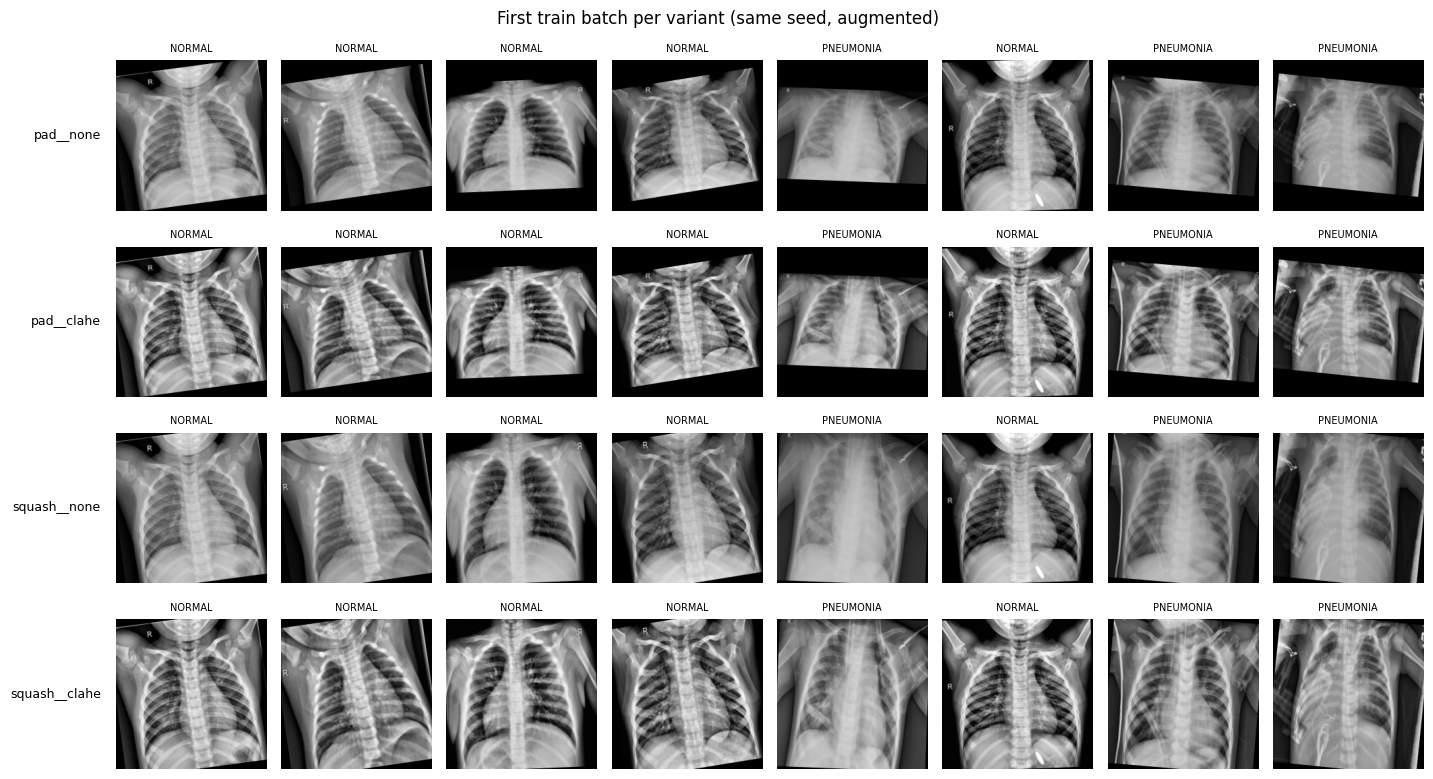

모든 변형의 첫 배치 라벨 순서 동일
train epoch sampled class ratio: {'NORMAL': '0.499', 'PNEUMONIA': '0.501'}
loader + augmentation only: 0.44s / epoch (148 batches)


In [11]:
# ---------- 확인: 변형별 train 배치 / 변형 간 샘플 순서 동일성 / sampler 클래스 비율 / 로더 속도 ----------
N_SHOW = 8


def to_display(x):
    """정규화를 되돌려 첫 채널만 [0,1] 흑백으로 본다."""
    return (x[:, 0] * IMAGENET_STD[0] + IMAGENET_MEAN[0]).clamp(0, 1).cpu().numpy()


# 같은 시드라 열마다 같은 이미지·같은 증강이 나온다 -> 행끼리 pad/squash, none/clahe 차이만 보인다
fig, axes = plt.subplots(len(VARIANTS), N_SHOW, figsize=(N_SHOW * 1.8, len(VARIANTS) * 2.0))
first_labels = {}
for r, name in enumerate(VARIANTS):
    x, y = next(iter(make_loaders(name)["train"]))
    first_labels[name] = y.cpu()
    print(f"{name:13s} shape={tuple(x.shape)} mean={x.mean():.3f} std={x.std():.3f}")
    imgs = to_display(x[:N_SHOW])
    for c, ax in enumerate(axes[r]):
        ax.imshow(imgs[c], cmap="gray", vmin=0, vmax=1)
        ax.set_title(CLASSES[y[c]], fontsize=7)
        ax.axis("off")
    axes[r][0].text(-0.1, 0.5, name, transform=axes[r][0].transAxes, ha="right", va="center", fontsize=9)
plt.suptitle("First train batch per variant (same seed, augmented)")
plt.tight_layout()
plt.show()

ref = next(iter(first_labels.values()))
assert all(torch.equal(ref, y) for y in first_labels.values()), "변형마다 sampler 순서가 다릅니다"
print("모든 변형의 첫 배치 라벨 순서 동일")

# sampler 적용 후 한 에폭 동안 뽑힌 클래스 비율과, 로더+증강만의 에폭 소요 시간
loader = make_loaders("pad__clahe")["train"]
t0 = time.time()
counts = torch.zeros(len(CLASSES), dtype=torch.long)
for x, y in loader:
    counts += torch.bincount(y.cpu(), minlength=len(CLASSES))
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
elif DEVICE.type == "mps":
    torch.mps.synchronize()
print("train epoch sampled class ratio:", {c: f"{n / counts.sum().item():.3f}" for c, n in zip(CLASSES, counts.tolist())})
print(f"loader + augmentation only: {time.time() - t0:.2f}s / epoch ({len(loader)} batches)")

# 2. 모델 정의

In [12]:
# ---------- 아키텍처별 이름 정리 ----------
# head: 2-class Linear로 교체할 분류층
# last_stage: Partial Fine-Tuning에서 head와 함께 푸는 특징 추출기의 마지막 stage (pooling 직전까지)
import torchvision.models as tvm

ARCH_SPECS = {
    "resnet50": {"ctor": tvm.resnet50, "weights": tvm.ResNet50_Weights.DEFAULT,
                 "head": "fc",
                 "last_stage": ["layer4"]},
    "densenet121": {"ctor": tvm.densenet121, "weights": tvm.DenseNet121_Weights.DEFAULT,
                    "head": "classifier",
                    "last_stage": ["features.denseblock4", "features.norm5"]},       # norm5: 마지막 block 뒤 BN
    "efficientnet_b0": {"ctor": tvm.efficientnet_b0, "weights": tvm.EfficientNet_B0_Weights.DEFAULT,
                        "head": "classifier.1",         # classifier.0 Dropout은 유지
                        "last_stage": ["features.7", "features.8"]},                  # 8: 마지막 1x1 conv(320->1280)
}
MODES = ["frozen", "partial", "full"]


def _set_submodule(model: nn.Module, name: str, module: nn.Module):
    parent, _, child = name.rpartition(".")
    setattr(model.get_submodule(parent) if parent else model, child, module)


def _under(param_name: str, prefixes) -> bool:
    return any(param_name == p or param_name.startswith(p + ".") for p in prefixes)


def build_model(arch: str, mode: str, pretrained: bool = True) -> nn.Module:
    """ImageNet 사전학습 모델 -> head를 2-class로 교체 -> 동결 모드 적용. 입력은 3채널."""
    spec = ARCH_SPECS[arch]
    model = spec["ctor"](weights=spec["weights"] if pretrained else None)

    head = model.get_submodule(spec["head"])
    _set_submodule(model, spec["head"], nn.Linear(head.in_features, len(CLASSES)))

    trainable = {"frozen": [spec["head"]], "partial": spec["last_stage"] + [spec["head"]], "full": None}[mode]
    for name, p in model.named_parameters():
        p.requires_grad = trainable is None or _under(name, trainable)
    return model


def split_params(model: nn.Module, arch: str):
    """(head 파라미터, 학습되는 backbone 파라미터) — optimizer의 차등 LR 그룹에 쓴다."""
    head_prefix = [ARCH_SPECS[arch]["head"]]
    head, backbone = [], []
    for name, p in model.named_parameters():
        if p.requires_grad:
            (head if _under(name, head_prefix) else backbone).append(p)
    return head, backbone

In [13]:
# ---------- 확인: 모드별 학습 파라미터 수 / forward 출력 shape ----------
rows = []
for arch in ARCH_SPECS:
    for mode in MODES:
        m = build_model(arch, mode)
        head, backbone = split_params(m, arch)
        total = sum(p.numel() for p in m.parameters())
        n_head, n_backbone = sum(p.numel() for p in head), sum(p.numel() for p in backbone)
        rows.append({"arch": arch, "mode": mode, "total(M)": total / 1e6, "trainable(M)": (n_head + n_backbone) / 1e6,
                     "head": n_head, "backbone(M)": n_backbone / 1e6, "trainable %": 100 * (n_head + n_backbone) / total})
display(pd.DataFrame(rows).round(3))

x, _ = next(iter(make_loaders("pad__none")["val"]))
for arch in ARCH_SPECS:
    m = build_model(arch, "full").to(DEVICE).eval()
    with torch.no_grad():
        logits = m(x)
    assert logits.shape == (x.size(0), len(CLASSES))
    print(f"{arch:16s} input {tuple(x.shape)} -> logits {tuple(logits.shape)}")
    del m

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 153MB/s] 


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 92.4MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 147MB/s]


,arch,mode,total(M),trainable(M),head,backbone(M),trainable %
0,resnet50,frozen,23.512,0.004,4098,0.000,0.017
1,resnet50,partial,23.512,14.969,4098,14.965,63.664
2,resnet50,full,23.512,23.512,4098,23.508,100.000
3,densenet121,frozen,6.956,0.002,2050,0.000,0.029
4,densenet121,partial,6.956,2.162,2050,2.160,31.084
5,densenet121,full,6.956,6.956,2050,6.954,100.000
6,efficientnet_b0,frozen,4.010,0.003,2562,0.000,0.064
7,efficientnet_b0,partial,4.010,1.132,2562,1.129,28.228
8,efficientnet_b0,full,4.010,4.010,2562,4.008,100.000


resnet50         input (32, 3, 224, 224) -> logits (32, 2)
densenet121      input (32, 3, 224, 224) -> logits (32, 2)
efficientnet_b0  input (32, 3, 224, 224) -> logits (32, 2)


# 3. 모델 학습
- 모델 기록은 텐서보드로 기록한다. 
- 코랩 무료 계정을 사용하기 때문에 3~5epoch마다 모델 가중치와 학습 기록을 저장해야 한다. 중간에 세션이 끊겼을 때 부작용을 최소화하고 다른 세션에서 학습을 바로 이어갈 수 있도록. 

In [14]:
# ---------- 학습 설정: 36 run(3모델 x 3모드 x 4변형) 모두 동일 ----------
ARCHS = list(ARCH_SPECS)
EPOCHS = 10                       # 고정 에폭, early stopping 없음 (best-val checkpoint로 선택)
LR_HEAD, LR_BACKBONE = 1e-3, 1e-4  # 새로 만든 head는 크게, 사전학습 backbone은 작게 — 이 규칙을 모든 모델/모드에 똑같이 적용
WEIGHT_DECAY = 1e-4
SAVE_EVERY = 3                    # colab 세션 끊김 대비: 3 에폭마다 재개용 checkpoint + history CSV 저장
MONITOR = "f1"
SUMMARY_PATH = RESULT_DIR / "summary.csv"   # 완료 run 요약 (여기 있는 run은 다시 돌리지 않는다)


def run_name_of(arch: str, mode: str, variant: str) -> str:
    return f"{arch}__{mode}__{variant}"


def make_optimizer(model: nn.Module, arch: str):
    head, backbone = split_params(model, arch)
    groups = [{"name": "head", "params": head, "lr": LR_HEAD}]
    if backbone:   # frozen은 backbone 그룹이 없다
        groups.append({"name": "backbone", "params": backbone, "lr": LR_BACKBONE})
    return torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)


def completed_runs(summary_path: Path = SUMMARY_PATH, hist_dir: Path = HIST_DIR, ckpt_dir: Path = CKPT_DIR,
                   epochs: int = EPOCHS) -> set:
    """완료 run = summary.csv에 있는 run + history가 epochs 행까지 차 있고 재개용 _last.pt가 없는 run.
    summary.csv가 없거나 행이 빠져 있어도(Run All 등) 끝난 run을 처음부터 다시 돌려 history/best를 덮어쓰지 않는다."""
    done = set(pd.read_csv(summary_path)["run"]) if summary_path.exists() else set()
    for path in hist_dir.glob("*.csv"):
        if not (ckpt_dir / f"{path.stem}_last.pt").exists() and len(pd.read_csv(path)) >= epochs:
            done.add(path.stem)
    return done

In [15]:
# ---------- run 하나: 학습 -> summary.csv 1행 추가 -> 재개용 checkpoint 삭제 ----------
def run_experiment(arch: str, mode: str, variant: str, epochs: int = EPOCHS):
    run = run_name_of(arch, mode, variant)
    sizing, clahe = VARIANTS[variant]
    seed_everything(SEED)   # head 초기화 / dropout 난수까지 run마다 같은 출발점
    loaders = make_loaders(variant)
    model = build_model(arch, mode).to(DEVICE)
    optimizer = make_optimizer(model, arch)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = fit(model, loaders["train"], loaders["val"], nn.CrossEntropyLoss(), optimizer, epochs, run,
                  scheduler=scheduler, monitor=MONITOR, save_every=SAVE_EVERY, resume=True)

    best = history[history["is_best"]].iloc[-1]
    row = {"run": run, "arch": arch, "mode": mode, "variant": variant, "sizing": sizing, "clahe": clahe,
           "epochs": epochs, "monitor": MONITOR, "best_epoch": int(best["epoch"]),
           **{c: best[c] for c in history.columns if c.startswith("val_")},
           "params_total": sum(p.numel() for p in model.parameters()),
           "params_trainable": sum(p.numel() for p in model.parameters() if p.requires_grad),
           "mean_epoch_sec": history["sec"].mean(), "total_sec": history["sec"].sum(),
           "finished_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}
    pd.DataFrame([row]).to_csv(SUMMARY_PATH, mode="a", header=not SUMMARY_PATH.exists(), index=False)
    (CKPT_DIR / f"{run}_last.pt").unlink(missing_ok=True)   # 완료됐으니 재개용 상태는 지운다 (best/history는 유지)
    return model, history

In [16]:
# ---------- 그리드 실행: 세션이 끊기면 이 셀만 다시 실행 ----------
# 완료 run(summary.csv에 있음)은 건너뛰고, 진행 중이던 run은 {run}_last.pt에서 이어간다.
# 같은 변형끼리 연달아 돌려 GPU에 올린 이미지 텐서를 재사용한다.
RUN_ONLY = None   # 일부만 돌릴 때: 예) {"arch": ["resnet50"], "mode": ["full"]}

grid = [(variant, arch, mode) for variant in VARIANTS for arch in ARCHS for mode in MODES]
done = completed_runs()
for variant, arch, mode in grid:
    cond = {"variant": variant, "arch": arch, "mode": mode}
    if RUN_ONLY and any(cond[k] not in v for k, v in RUN_ONLY.items()):
        continue
    run = run_name_of(arch, mode, variant)
    if run in done:
        print(f"[{run}] 완료됨 - skip")
        continue
    model, _ = run_experiment(arch, mode, variant)
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE.type == "mps":
        torch.mps.empty_cache()

[resnet50__frozen__pad__none] 완료됨 - skip
[resnet50__partial__pad__none] 완료됨 - skip
[resnet50__full__pad__none] 완료됨 - skip
[densenet121__frozen__pad__none] 완료됨 - skip
[densenet121__partial__pad__none] 완료됨 - skip
[densenet121__full__pad__none] 완료됨 - skip
[efficientnet_b0__frozen__pad__none] 완료됨 - skip
[efficientnet_b0__partial__pad__none] 완료됨 - skip
[efficientnet_b0__full__pad__none] 완료됨 - skip
[resnet50__frozen__pad__clahe] 완료됨 - skip
[resnet50__partial__pad__clahe] 완료됨 - skip
[resnet50__full__pad__clahe] 완료됨 - skip
[densenet121__frozen__pad__clahe] 완료됨 - skip
[densenet121__partial__pad__clahe] 완료됨 - skip
[densenet121__full__pad__clahe] 완료됨 - skip
[efficientnet_b0__frozen__pad__clahe] 완료됨 - skip
[efficientnet_b0__partial__pad__clahe] 완료됨 - skip
[efficientnet_b0__full__pad__clahe] 완료됨 - skip
[resnet50__frozen__squash__none] 완료됨 - skip
[resnet50__partial__squash__none] 완료됨 - skip
[resnet50__full__squash__none] 완료됨 - skip
[densenet121__frozen__squash__none] 완료됨 - skip
[densenet121__partial

In [17]:
# ---------- 진행 현황 ----------
# TensorBoard: 4장 첫 셀(start_tensorboard)로 띄운다. colab이면 로컬 브라우저용 공개 URL도 만든다.
if SUMMARY_PATH.exists():
    summary = pd.read_csv(SUMMARY_PATH)
    print(f"완료 {len(summary)} / {len(VARIANTS) * len(ARCHS) * len(MODES)} run")
    display(summary[["run", "best_epoch", "val_recall", "val_f1", "val_roc_auc", "val_accuracy", "mean_epoch_sec"]]
            .sort_values("val_f1", ascending=False).round(4))
else:
    print("아직 완료된 run이 없습니다.")

완료 36 / 36 run


,run,best_epoch,val_recall,val_f1,val_roc_auc,val_accuracy,mean_epoch_sec
29,resnet50__full__squash__clahe,8,0.9946,0.9932,0.9976,0.9901,64.7193
26,efficientnet_b0__full__squash__none,10,0.9919,0.9932,0.9993,0.9901,26.8909
32,densenet121__full__squash__clahe,1,0.9946,0.9919,0.9967,0.9882,56.0217
20,resnet50__full__squash__none,6,0.9919,0.9919,0.9983,0.9882,64.8018
2,resnet50__full__pad__none,10,0.9892,0.9918,0.9974,0.9882,64.5119
5,densenet121__full__pad__none,1,0.9946,0.9906,0.9972,0.9862,55.5922
19,resnet50__partial__squash__none,7,0.9946,0.9906,0.9967,0.9862,26.0175
14,densenet121__full__pad__clahe,1,0.9919,0.9905,0.9973,0.9862,55.8914
23,densenet121__full__squash__none,5,0.9919,0.9905,0.9978,0.9862,55.9037
31,densenet121__partial__squash__clahe,10,0.9892,0.9905,0.9979,0.9862,19.9072


# 4. Train/Validation 평가
- 실험 대조군들의 epoch 별 **train/val 학습 곡선**을 확인한다. 
- 폐렴 예측 과제를 가장 잘 수행하는 **모델 x 전이학습 조합**을 확인한다. 
- 그 조합에서 사용된 **데이터셋 전처리 전략**은 무엇이었는 지 확인한다. 
- 결과에 대해 **설명**할 수 있다.

In [ ]:
# 텐서보드 접속 하기
# 코랩 접속 환경 및 로컬 환경인지에 따라 텐서보드 프로세스를 띄우고 접속 url을 안내한다.
# - 로컬: 이 커널에서 tensorboard를 띄우고 http://localhost:6006 으로 접속한다.
# - colab: colab VM 안에서 tensorboard를 띄우고 cloudflared quick tunnel(계정/토큰 불필요)로 공개 URL을 만든다.
#   colab 웹 화면이든, 로컬 VS Code/Jupyter가 colab 런타임에 붙은 상태든 로컬 브라우저에서 그 URL로 접속하면 된다.
#   URL을 아는 사람은 누구나 볼 수 있다(학습 곡선만 노출). 공유하지 말고, 다 보면 stop_tensorboard()로 끈다.
import shutil
import socket
import subprocess
import tempfile

flag_connect_tensorboard = False
TB_PORT = 6006
TB_LOG = Path(tempfile.gettempdir()) / "tensorboard_proc.log"
CF_LOG = Path(tempfile.gettempdir()) / "cloudflared_proc.log"
CF_URL_RE = re.compile(r"https://[-a-z0-9]+\.trycloudflare\.com")
_TB_PROCS = globals().get("_TB_PROCS", {})   # 셀을 다시 실행해도 이미 띄운 프로세스를 재사용한다


def _port_open(port: int) -> bool:
    with socket.socket() as s:
        s.settimeout(0.5)
        return s.connect_ex(("127.0.0.1", port)) == 0


def _alive(name: str) -> bool:
    p = _TB_PROCS.get(name)
    return p is not None and p.poll() is None


def start_tensorboard(logdir: Path = TB_DIR, port: int = TB_PORT, timeout: float = 60):
    if _port_open(port):
        print(f"tensorboard가 이미 {port} 포트에서 실행 중입니다.")
        return
    log = open(TB_LOG, "w")
    _TB_PROCS["tensorboard"] = subprocess.Popen(
        [sys.executable, "-m", "tensorboard.main", "--logdir", str(logdir), "--port", str(port),
         "--host", "127.0.0.1", "--reload_interval", "30"],   # Drive 위 로그를 너무 자주 다시 읽지 않도록 30초
        stdout=log, stderr=subprocess.STDOUT)
    t0 = time.time()
    while not _port_open(port):
        if not _alive("tensorboard") or time.time() - t0 > timeout:
            raise RuntimeError(f"tensorboard 실행 실패. 로그: {TB_LOG}\n{TB_LOG.read_text()[-2000:]}")
        time.sleep(1)


def _cloudflared_bin() -> str:
    found = shutil.which("cloudflared")
    if found:
        return found
    path = Path(tempfile.gettempdir()) / "cloudflared"
    if not path.exists():   # colab(linux x86_64)용 단일 실행 파일
        subprocess.run(["wget", "-q", "-O", str(path),
                        "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64"],
                       check=True)
        path.chmod(0o755)
    return str(path)


def open_tunnel(port: int = TB_PORT, timeout: float = 60) -> str:
    if _alive("cloudflared") and _TB_PROCS.get("url"):
        return _TB_PROCS["url"]
    log = open(CF_LOG, "w")
    _TB_PROCS["cloudflared"] = subprocess.Popen(
        [_cloudflared_bin(), "tunnel", "--no-autoupdate", "--url", f"http://127.0.0.1:{port}"],
        stdout=log, stderr=subprocess.STDOUT)
    t0 = time.time()
    while time.time() - t0 < timeout:
        m = CF_URL_RE.search(CF_LOG.read_text())
        if m:
            _TB_PROCS["url"] = m.group(0)
            return m.group(0)
        if not _alive("cloudflared"):
            break
        time.sleep(1)
    raise RuntimeError(f"cloudflared URL을 받지 못했습니다. 로그: {CF_LOG}\n{CF_LOG.read_text()[-2000:]}")


def stop_tensorboard():
    for name in ("cloudflared", "tensorboard"):
        if _alive(name):
            _TB_PROCS[name].terminate()
    _TB_PROCS.clear()
    print("tensorboard / tunnel 종료")


if flag_connect_tensorboard:
    start_tensorboard()
    if IN_COLAB:
        url = open_tunnel()
        print(f"로컬 브라우저에서 접속: {url}\n(터널이 막 열린 직후엔 몇 초 뒤 새로고침, 끄기: stop_tensorboard())")
    else:
        print(f"로컬 브라우저에서 접속: http://localhost:{TB_PORT}  (끄기: stop_tensorboard())")

history: 36 / 36 run


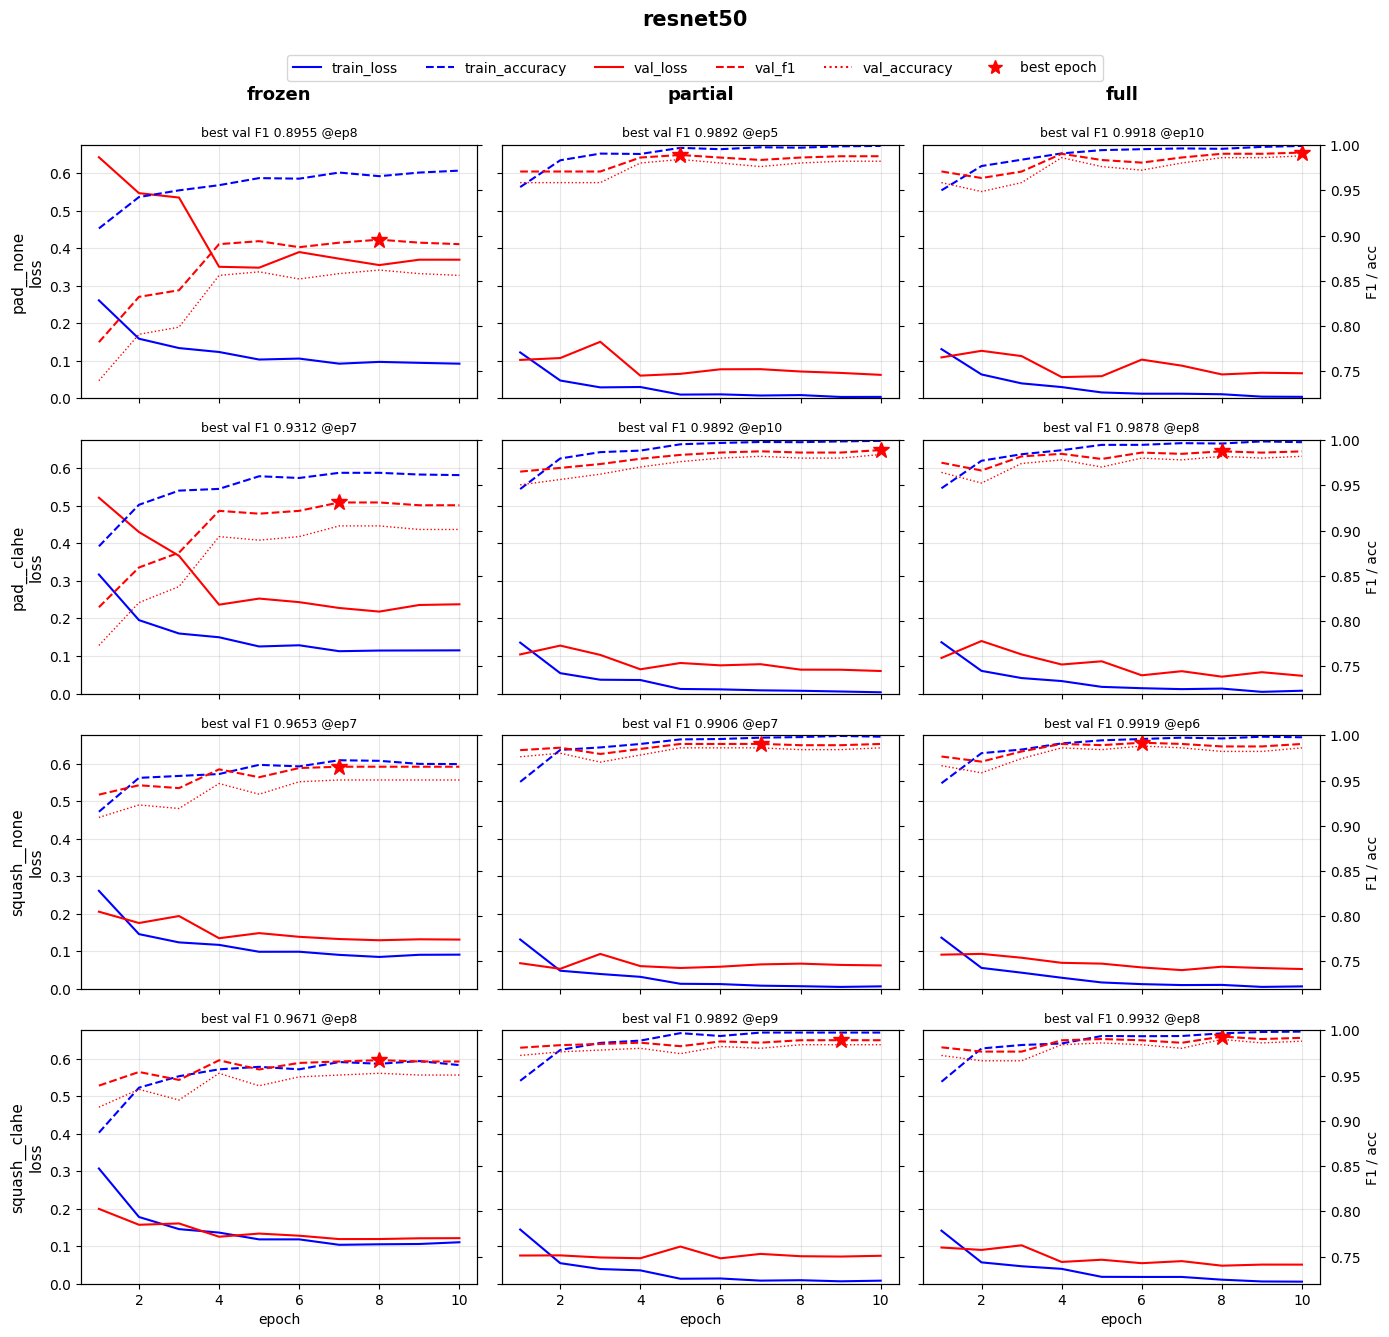

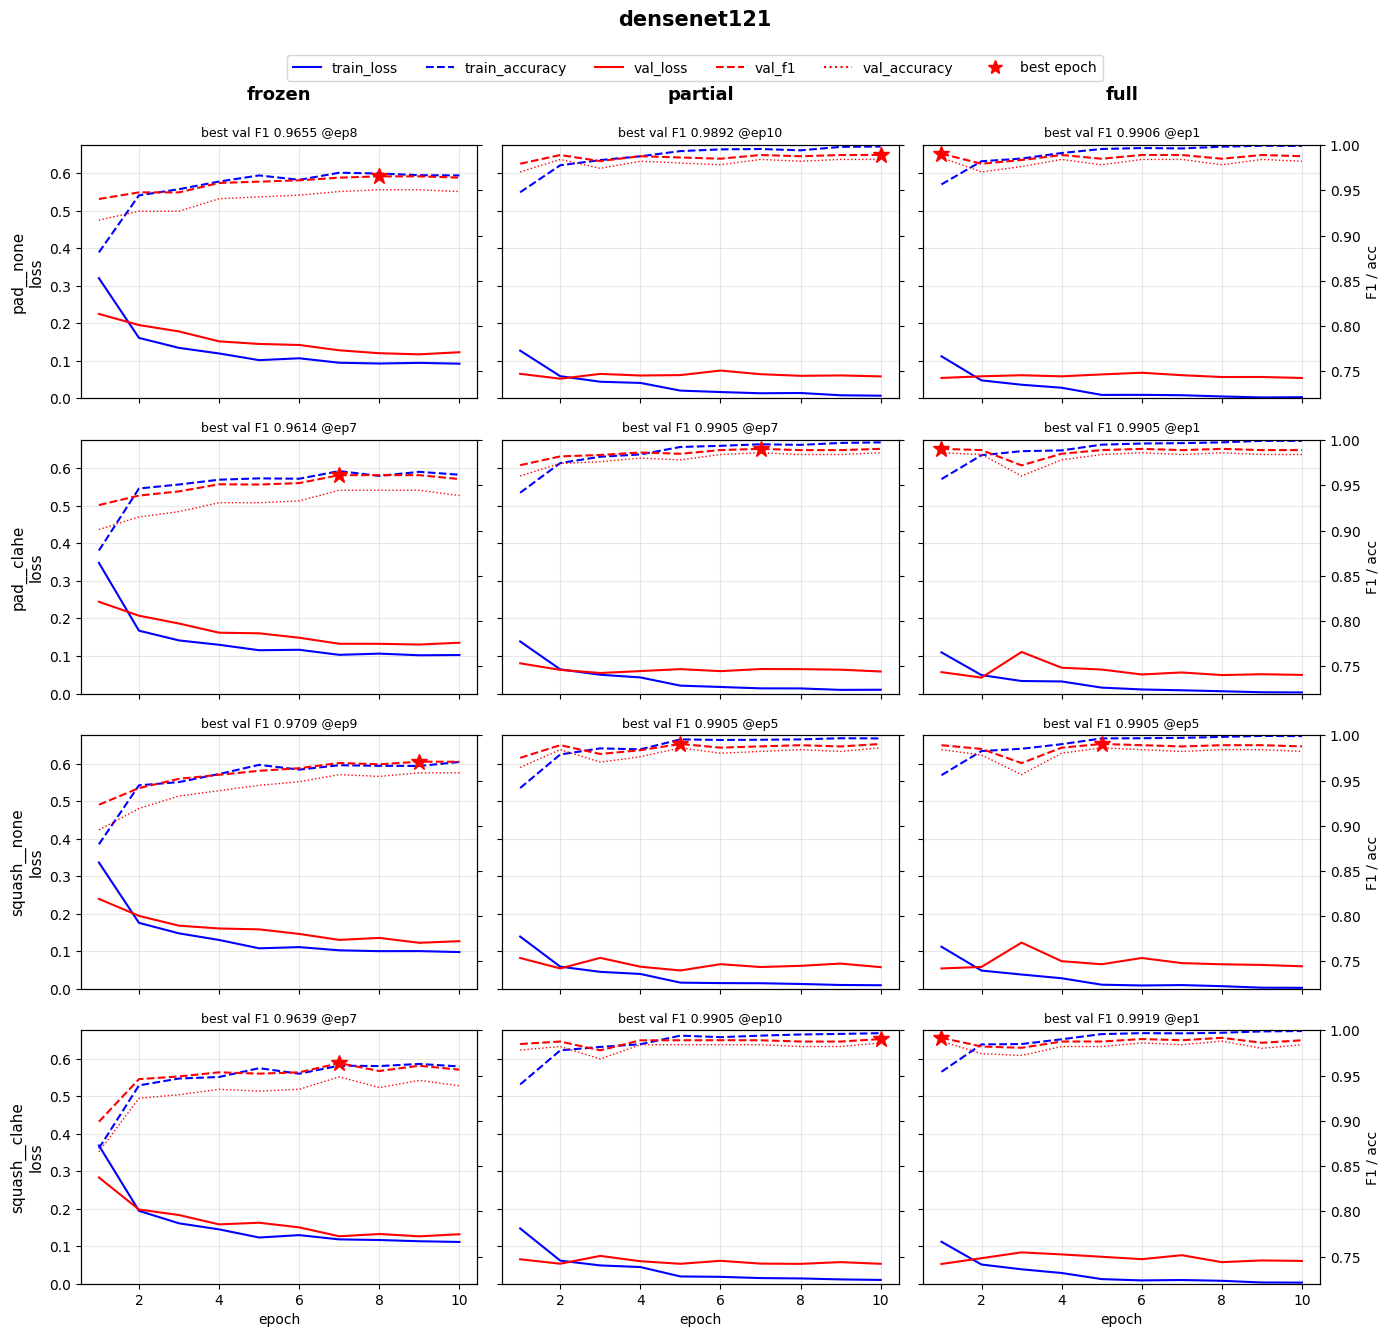

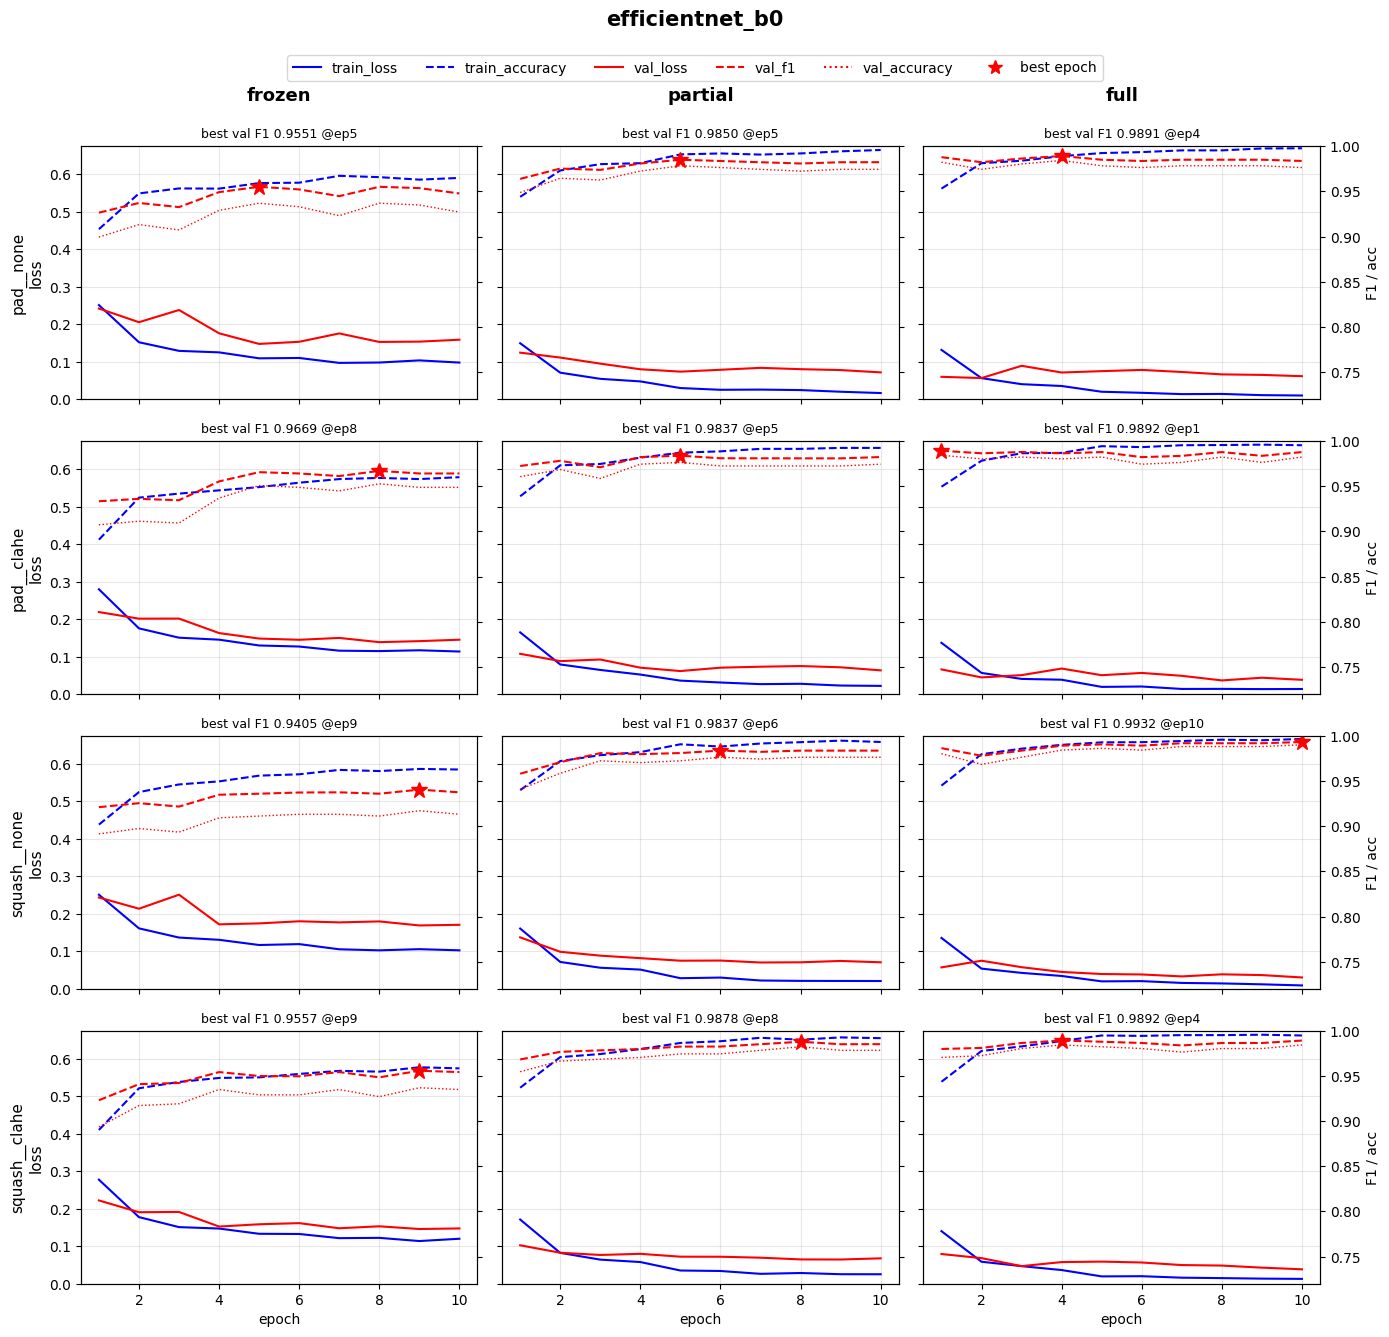

In [19]:
# 36개 run의 학습 곡선을 한 화면에 그려 비교한다. (TensorBoard를 켜지 않아도 확인 가능)
# 과적합, 학습률, 전처리 변형, 모델/모드별 성능 차이를 한눈에 볼 수 있다.
# - 도표
#   - 각 모델 별로 12개 그래프를 모두 그린다. 각 모델 별로 행으로는 데이터 전처리방식 4가지, 열로는 학습방식 3개지 grid로 그린다.
#   - 총 36개 그래프가 보인다.
#   - 각 그래프: x = epoch, y_1 = loss, y_2 = f1.
#   - 각 그래프에는 꺾은선이 총 4개 보인다. train_loss(파란색 실선), train_f1(파란색 점선), val_loss(빨간색 실선), val_f1(빨간색 점선)
#
# history/{run}.csv만 읽으므로 0장(상수/경로)만 실행하면 된다. ★ = best epoch(val F1 최고, _best.pt에 저장된 에폭).
# train F1은 학습 때 기록하지 않았으므로(history에 train_loss/train_accuracy만 있음) 그 자리에 train accuracy를 그린다.
#   이때는 비교 짝을 맞추려고 val accuracy(빨간 점선, 얇게)도 함께 그린다.
# 주의: train 지표는 WeightedRandomSampler(클래스 1:1) + 증강이 걸린 배치에서, val 지표는 원래 분포에서 계산된다.
#   그래서 train/val의 절대 차이를 그대로 과적합으로 읽지 말고, 에폭이 지나며 차이가 벌어지는지(추세)를 본다.
from matplotlib.lines import Line2D

ARCH_ORDER = ["resnet50", "densenet121", "efficientnet_b0"]
MODE_ORDER = ["frozen", "partial", "full"]
VARIANT_ORDER = ["pad__none", "pad__clahe", "squash__none", "squash__clahe"]


def load_histories(hist_dir: Path = HIST_DIR) -> pd.DataFrame:
    frames = []
    for path in sorted(hist_dir.glob("*.csv")):
        arch, mode, variant = path.stem.split("__", 2)
        sizing, clahe = variant.split("__")
        frames.append(pd.read_csv(path).assign(run=path.stem, arch=arch, mode=mode, variant=variant,
                                               sizing=sizing, clahe=clahe))
    return pd.concat(frames, ignore_index=True)


hist = load_histories()
n_epochs = hist.groupby("run")["epoch"].max()
print(f"history: {hist['run'].nunique()} / {len(ARCH_ORDER) * len(MODE_ORDER) * len(VARIANT_ORDER)} run")
if n_epochs.nunique() > 1:
    print("에폭 수가 다른(학습 중이던) run:", n_epochs[n_epochs < n_epochs.max()].to_dict())

TRAIN_SCORE = "train_f1" if "train_f1" in hist else "train_accuracy"
SCORE_COLS = [TRAIN_SCORE, "val_f1"] + ([] if TRAIN_SCORE == "train_f1" else ["val_accuracy"])
LOSS_MAX = hist[["train_loss", "val_loss"]].max().max() * 1.05
SCORE_MIN = max(0.0, np.floor((hist[SCORE_COLS].min().min() - 0.01) * 50) / 50)


def plot_curves(arch: str):
    fig, axes = plt.subplots(len(VARIANT_ORDER), len(MODE_ORDER), figsize=(14, 13), sharex=True, sharey=True)
    for i, variant in enumerate(VARIANT_ORDER):
        for j, mode in enumerate(MODE_ORDER):
            ax = axes[i, j]
            ax2 = ax.twinx()
            d = hist[(hist["arch"] == arch) & (hist["mode"] == mode) & (hist["variant"] == variant)].sort_values("epoch")
            if not d.empty:
                ax.plot(d["epoch"], d["train_loss"], "b-", lw=1.5)
                ax.plot(d["epoch"], d["val_loss"], "r-", lw=1.5)
                ax2.plot(d["epoch"], d[TRAIN_SCORE], "b--", lw=1.5)
                ax2.plot(d["epoch"], d["val_f1"], "r--", lw=1.5)
                if TRAIN_SCORE != "train_f1":
                    ax2.plot(d["epoch"], d["val_accuracy"], "r:", lw=1)
                best = d[d["is_best"]].iloc[-1]
                ax2.plot(best["epoch"], best["val_f1"], "r*", ms=12)
                ax.set_title(f"best val F1 {best['val_f1']:.4f} @ep{int(best['epoch'])}", fontsize=9)
            ax.set_ylim(0, LOSS_MAX)
            ax2.set_ylim(SCORE_MIN, 1.0)
            ax2.tick_params(labelright=(j == len(MODE_ORDER) - 1))
            ax.grid(alpha=0.3)
            if i == 0:
                ax.annotate(mode, (0.5, 1.18), xycoords="axes fraction", ha="center", fontsize=13, weight="bold")
            if j == 0:
                ax.set_ylabel(f"{variant}\nloss", fontsize=11)
            if j == len(MODE_ORDER) - 1:
                ax2.set_ylabel("F1" if TRAIN_SCORE == "train_f1" else "F1 / acc")
            if i == len(VARIANT_ORDER) - 1:
                ax.set_xlabel("epoch")
    handles = [Line2D([], [], color="b", ls="-", label="train_loss"),
               Line2D([], [], color="b", ls="--", label=TRAIN_SCORE),
               Line2D([], [], color="r", ls="-", label="val_loss"),
               Line2D([], [], color="r", ls="--", label="val_f1")]
    if TRAIN_SCORE != "train_f1":
        handles.append(Line2D([], [], color="r", ls=":", label="val_accuracy"))
    handles.append(Line2D([], [], color="r", marker="*", ls="", ms=10, label="best epoch"))
    fig.legend(handles=handles, loc="upper center", ncol=len(handles), bbox_to_anchor=(0.5, 0.995))
    fig.suptitle(arch, y=1.025, fontsize=15, weight="bold")
    fig.tight_layout()
    plt.show()


for arch in ARCH_ORDER:
    plot_curves(arch)

## 4.1. 학습 곡선 평가

1. **발견**
    - **frozen이 partial, full보다 성능이 떨어진다.** 
        - frozen은 다른 학습방법들보다 갱신하는 가중치가 훨씬 적다. 백본은 ImageNet 가중치 그대로이고, 마지막 분류층만 학습한다. 
        - 그런데도 frozen의 마지막 에폭 val F1은 평균 0.950이다. 즉, ImageNet에서 학습한 특징만으로도 폐렴 판단에 꽤 유의미하다. 다만 백본을 X-ray에 맞게 고쳤을 때(full) F1이 약 0.04 더 올랐다(full - frozen 평균 +0.0375). 
        - 그래프를 보면, frozen에서 train, validation loss가 시작하는 출발점이 partial, full에 비해 높은 것을 알 수 있다. 
            - epoch 1의 train loss는 1에폭 동안의 평균이다. partial, full은 학습하는 가중치가 많아 첫 에폭 안에서 이미 빠르게 내려가므로 출발점이 낮다(train loss 약 0.13 vs frozen 약 0.30). 
        - 그리고, epoch 1에서의 loss와 epoch 10에서의 loss의 차이가 frozen이 partial, full에 비해 크다. 
            - 하지만 frozen에서 백본 가중치는 전혀 바뀌지 않으므로, 이를 ImageNet 가중치에서 변경할 점이 많았다고 해석할 수는 없다. loss의 출발점이 높아 분류층 하나로 내려갈 거리가 더 많이 남아 있었을 뿐이다. 
            - 또한 frozen 12개 run 중 10개가 val loss 최저점을 8~9 에폭에 찍었다. 즉, 10 에폭에서도 아직 수렴하지 않았다. 따라서 "frozen이 떨어진다"는 **10 에폭 기준**의 결론이다. 
    - **partial, full에서, train의 loss, acc 개선도에 비해 validation loss, f1 개선도가 더 작았다.** 
        - 즉, epoch이 진행됨에 따라 val loss, f1은 변화가 그렇게 크지 않았다는 것이다. 대부분 1~2 에폭 이후로는 val 성능이 더 오르지 않았다. 
        - ***다만 과적합 신호는 약하게 보인다.*** 
        - 일부 run은 train loss가 0.003까지 떨어지는 동안 val loss가 최저점 이후 조금씩 늘어났다. 
            - 예) densenet121/full/squash/clahe: val loss 최저 1 에폭, 이후 +0.0081 / resnet50/full/pad/none: 최저 4 에폭, 이후 +0.0102 
            - 바로 아래 셀에서 확인 가능한 히트맵에서 densenet121 full의 best epoch이 1인 것도 같은 현상이다. 
        - 그럼에도 validation acc, f1은 모두 0.98정도로 일관되게 높았다. 틀리는 장수는 그대로이고, 이미 틀린 몇 장에 대한 확신만 강해졌다는 뜻이다. 따라서 아직 F1에 드러날 정도의 과적합은 아니다. 
    - **하지만 대부분의 경우에서 train loss가 수렴하는 기울기보다, validation loss가 수렴하는 기울기가 더 작았다.**
        - 이정도의 차이는 대체로 일반적인 것이다. 그리고 두 곡선은 애초에 같은 조건에서 잰 값이 아니라서 기울기를 직접 비교하기 어렵다. 
            - train loss: 증강이 들어간 상태에서 에폭 동안의 평균 / val loss: 에폭이 끝난 뒤 증강 없이 측정 
            - train: sampler로 클래스 비율 약 50:50 / val: PNEUMONIA 73% (369/507) 클래스 비율 그대로 측정. 
    - **ResNet50 frozen에서, padding으로 사이즈를 맞췄을 때, train과 validation loss와 acc, f1의 차이가 다른 경우보다 훨씬 컸다.**
        - 마지막 에폭 loss 차이(val - train): frozen pad 0.200 vs squash 0.026. partial, full에서는 pad와 squash의 차이가 거의 없다(0.05~0.06). 
        - 왜 굳이 ResNet50 frozen에서 이런 차이가 났는 지 분석해볼 가치가 있다. 
            - 가설: frozen은 백본의 BN 통계가 ImageNet 값으로 고정된다(`set_frozen_eval`). pad의 검은 여백이 고정된 BN 통계와 일치하지 않아서 이걸 갱신해야하는데, 백본을 고칠 수 없어 보정하지 못했을 수 있다. partial, full에서 차이가 사라진다는 점이 이 가설을 뒷받침한다.

2. **한계**
    - colab 무료 계정과 드라이브 용량의 한계로 인해 epoch을 10까지밖에 하지 못했다. 리소스가 허용하는 한 30에폭까지는 돌려봐야 할 것으로 생각된다. 특히 frozen은 10 에폭에서 아직 수렴하지 않았다. 
    - 마찬가지 이유로 한 번의 train, validation만 기록한 결과다. seed도 하나뿐이다. 
    - validation이 507장뿐이라, 1장을 더 맞추거나 틀리면 F1이 약 0.0014 움직인다. 이 이하의 차이는 우연과 구분하기 어렵다. 
    - 학습률이 모든 학습방식에서 같다(head 1e-3, backbone 1e-4). frozen에 불리한 설정일 수 있다. 
    - train 기록에서 f1을 넣지 않았다. acc만 기록했다. recall, precision, f1, acc를 모두 기록해서 다시 한 번 점검해볼 필요가 있다. 

val 507장 (PNEUMONIA 369장) -> 1장 오분류가 F1을 약 0.0014 움직인다


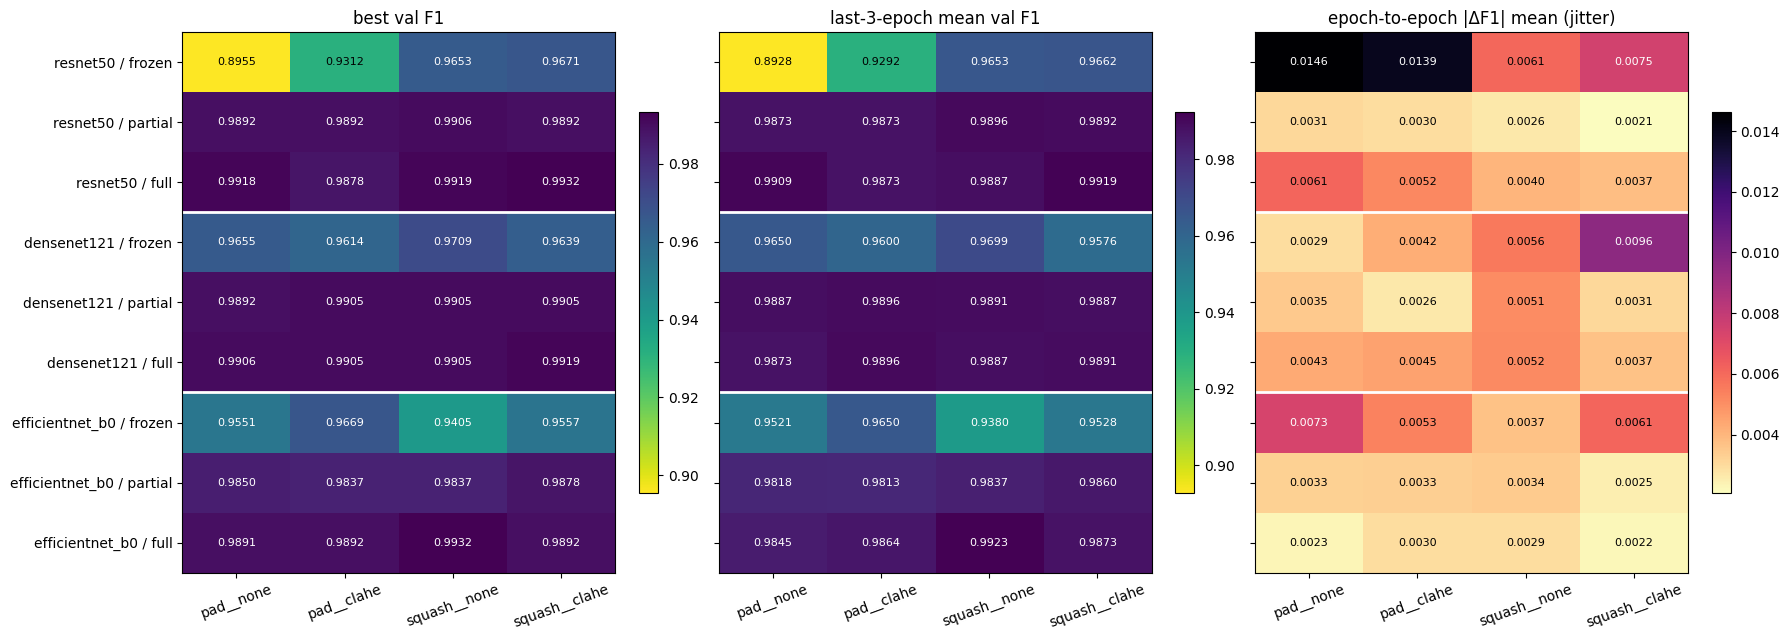

상위 10개 run (기준: last3_f1 = 마지막 3에폭 평균 val F1, 내림차순)


,run,best_epoch,best_f1,last3_f1,best_auc,jitter_f1
19,efficientnet_b0__full__squash__none,10,0.9932,0.9923,0.9993,0.0029
30,resnet50__full__squash__clahe,8,0.9932,0.9919,0.9976,0.0037
29,resnet50__full__pad__none,10,0.9918,0.9909,0.9974,0.0061
4,densenet121__full__pad__clahe,1,0.9905,0.9896,0.9973,0.0045
35,resnet50__partial__squash__none,7,0.9906,0.9896,0.9967,0.0026
8,densenet121__partial__pad__clahe,7,0.9905,0.9896,0.9970,0.0026
34,resnet50__partial__squash__clahe,9,0.9892,0.9892,0.9964,0.0021
6,densenet121__full__squash__clahe,1,0.9919,0.9891,0.9967,0.0037
11,densenet121__partial__squash__none,5,0.9905,0.9891,0.9983,0.0051
7,densenet121__full__squash__none,5,0.9905,0.9887,0.9978,0.0052


In [20]:
# ---------- run별 요약 히트맵: best val F1 / 마지막 3에폭 평균 val F1 / 에폭 간 흔들림 ----------
# best F1은 10개 에폭 중 최댓값이라 운 좋은 에폭 하나에 끌려갈 수 있다 -> 마지막 3에폭 평균(last3)을 함께 본다.
# jitter = 연속한 두 에폭 사이 val F1 변화량(절댓값)의 평균. 같은 설정 안에서 에폭마다 얼마나 흔들리는지.
# 행 = 모델 x 학습방식(9), 열 = 전처리 변형(4). 색은 패널마다 따로 스케일한다.
# 색 방향: 모든 패널에서 짙을수록 값이 크다 (F1은 짙을수록 좋고, jitter는 짙을수록 많이 흔들린다).
def summarize_runs(hist: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for run, d in hist.groupby("run", sort=False):
        d = d.sort_values("epoch")
        best = d[d["is_best"]].iloc[-1]
        rows.append({"run": run, **d.iloc[0][["arch", "mode", "variant", "sizing", "clahe"]].to_dict(),
                     "best_epoch": int(best["epoch"]), "best_f1": best["val_f1"], "best_auc": best["val_roc_auc"],
                     "last3_f1": d["val_f1"].tail(3).mean(),
                     "jitter_f1": d["val_f1"].diff().abs().mean()})
    return pd.DataFrame(rows)


runs = summarize_runs(hist)

# val 1장을 더 틀리면 F1이 얼마나 변하나: F1 = 2TP / (2TP + FP + FN) -> 분모가 1 늘 때 약 F1 / (2TP + FP + FN)
_v = hist.iloc[0]
n_val, n_val_pos = int(_v[["val_tn", "val_fp", "val_fn", "val_tp"]].sum()), int(_v["val_fn"] + _v["val_tp"])
ONE_SAMPLE_F1 = 1 / (2 * n_val_pos)
print(f"val {n_val}장 (PNEUMONIA {n_val_pos}장) -> 1장 오분류가 F1을 약 {ONE_SAMPLE_F1:.4f} 움직인다")

PANELS = [("best_f1", "best val F1", "viridis_r"), ("last3_f1", "last-3-epoch mean val F1", "viridis_r"),
          ("jitter_f1", "epoch-to-epoch |ΔF1| mean (jitter)", "magma_r")]
row_keys = [(a, m) for a in ARCH_ORDER for m in MODE_ORDER]
fig, axes = plt.subplots(1, len(PANELS), figsize=(18, 6.5))
for ax, (col, title, cmap) in zip(axes, PANELS):
    mat = (runs.pivot_table(index=["arch", "mode"], columns="variant", values=col)
           .reindex(index=pd.MultiIndex.from_tuples(row_keys), columns=VARIANT_ORDER))
    im = ax.imshow(mat.values, cmap=cmap, aspect="auto")
    for (r, c), v in np.ndenumerate(mat.values):
        if not np.isnan(v):
            ax.text(c, r, f"{v:.4f}", ha="center", va="center", fontsize=8,
                    color="white" if np.dot(im.cmap(im.norm(v))[:3], [0.299, 0.587, 0.114]) < 0.5 else "black")
    ax.set_xticks(range(len(VARIANT_ORDER)), VARIANT_ORDER, rotation=20)
    ax.set_yticks(range(len(row_keys)), [f"{a} / {m}" for a, m in row_keys] if ax is axes[0] else [])
    for k in range(1, len(ARCH_ORDER)):
        ax.axhline(k * len(MODE_ORDER) - 0.5, color="white", lw=2)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.04)
fig.tight_layout()
plt.show()

# 표: last3_f1(마지막 3에폭 평균 val F1) 내림차순 상위 10개 run. best_f1 열은 정렬 기준이 아니다.
TOP_K = 10
print(f"상위 {TOP_K}개 run (기준: last3_f1 = 마지막 3에폭 평균 val F1, 내림차순)")
display(runs.sort_values("last3_f1", ascending=False)
        [["run", "best_epoch", "best_f1", "last3_f1", "best_auc", "jitter_f1"]].head(TOP_K).round(4))

## 4.2. 가장 성능이 좋았던 조합

- **발견**
    - 히트맵에서 가장 어두운 부분이 가장 성능이 좋았던 부분이다. **last 3-epoch mean of validation F1은 EfficientNetB0 + full finetuning + squash + CLAHE(X)이 가장 좋았다(0.9923).**
        - 단일 best validation F1은 **ResNet50 + full + squash + CLAHE(0.99323)**와 사실상 공동 1위다(0.99322, 차이 0.00001). 
        - 그리고 last3 기준 1위와 10위의 차이가 0.0036, validation 2~3장 수준이다. 따라서 이 조합을 확실한 1위라고 보기는 어렵다. 
        - 따라서, ResNet Frozen, DenseNet Frozen, EfficientNet Frozen을 제외하고는 거의 성능이 비슷하다. 
        
    - **EfficientNet이 가장 좋은 arch라는 뜻은 아니다.** 
        - partial, full만 놓고 arch별 last3 F1 평균을 보면 ResNet50 0.9890, DenseNet121 0.9888, EfficientNetB0 0.9854로 오히려 EfficientNet이 가장 낮다. 
        - 1위 run 하나가 좋았을 뿐, arch 전반이 좋았던 것은 아니다. 
    - **full finetuning의 성능이 partial finetuning보다 약간 좋거나 비슷했다.** 
        - 상위 10개 run 중 6개가 full fine tuning이었고, 상위 5개 중 4개가 full finetuning이었다. 
        - 상위 10개 run 중에 Frozen은 끼지 못했다. 
        - 다만 같은 arch, 전처리끼리 짝지어 보면 full - partial의 last3 F1 평균 차이는 +0.0018(validation 약 1장)이다. 

- **결론**
    - validation 기준으로 ***모델 간의 성능 차이는 없다***. 
    - 하지만 ***학습방법(Frozen, Partial, Full)은 차이***가 있다. 특히 Frozen이 좋지 않았고, Full이 Partial보다 성능이 근소 우위에 있다.

- **주의**
    - 가장 좋은 조합을 validation으로 고르고, 그 성능을 다시 validation으로 보고하면 실제보다 낙관적인 값이 된다. 최종 성능은 test에서 확인한다. 

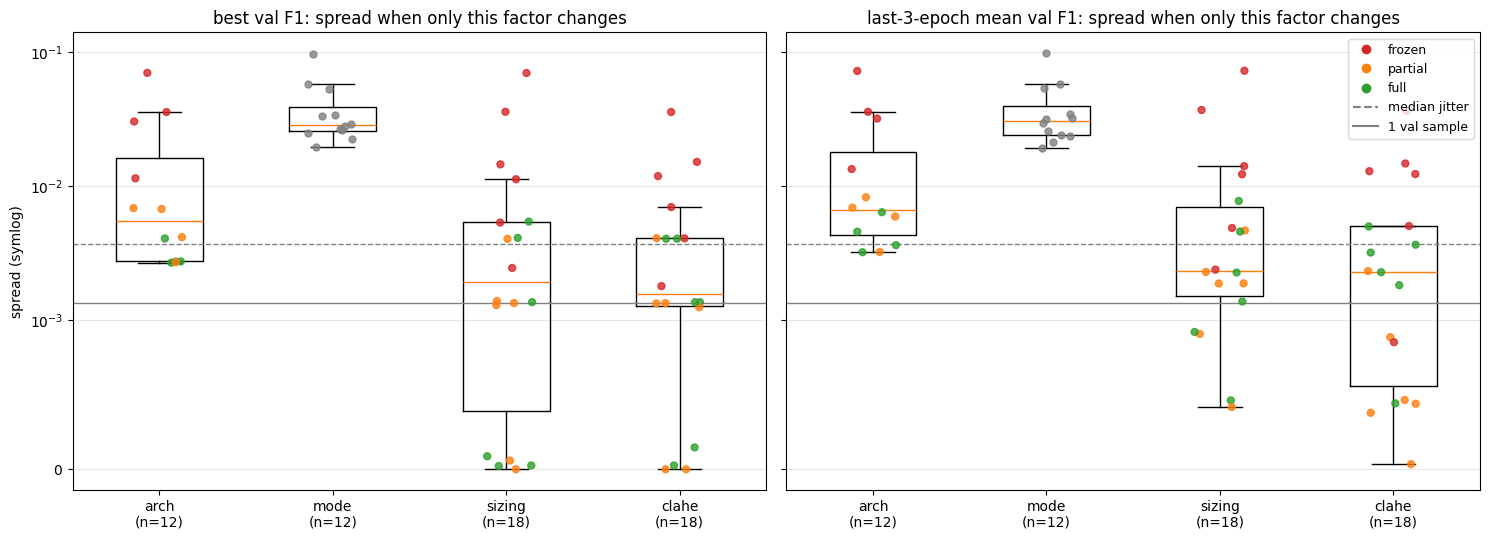

count    mean  median     max
best val F1              arch     12.0  0.0150  0.0055  0.0700
                         mode     12.0  0.0376  0.0285  0.0963
                         sizing   18.0  0.0088  0.0019  0.0698
                         clahe    18.0  0.0053  0.0016  0.0357
last-3-epoch mean val F1 arch     12.0  0.0163  0.0067  0.0723
                         mode     12.0  0.0377  0.0306  0.0982
                         sizing   18.0  0.0096  0.0023  0.0726
                         clahe    18.0  0.0057  0.0023  0.0364

흔들림 큰 순서 (last3 F1 spread 중앙값): mode(0.0306) > arch(0.0067) > sizing(0.0023) > clahe(0.0023)



#### sizing: **squash** vs **pad**
같은 모델·학습방식·나머지 전처리에서 sizing만 다른 run 두 개를 한 짝으로 묶고, 짝마다 **차이 = squash 지표 − pad 지표**를 계산한다.

| 컬럼 | 의미 |
|--|--|
| 지표 | 비교에 쓴 값. best val F1 = 10에폭 중 최고 val F1, last-3-epoch mean val F1 = 마지막 3에폭 평균 val F1 |
| 범위 | 전체 = 18짝 전부, frozen/partial/full = 그 학습방식의 짝만 |
| 짝 수 | 비교한 짝의 개수 |
| squash 승 | 차이 ≥ +0.0014 (val 1장 이상 더 맞힘): **squash 쪽이 더 좋았던** 짝 수 |
| pad 승 | 차이 ≤ −0.0014: **pad 쪽이 더 좋았던** 짝 수 |
| 실질 동률 | \|차이\| < 0.0014: val 1장 오분류보다 작은 차이라 우열을 가릴 수 없는 짝 수 |
| 평균 차이 (squash-pad) | 차이의 평균. 양수면 평균적으로 squash 쪽이 높다 (큰 짝 하나에 끌려갈 수 있으니 승패 수와 함께 본다) |
| 최소 (pad 최대 우세) | 가장 작은 차이. 음수면 pad 쪽이 가장 크게 이긴 짝의 격차 |
| 최대 (squash 최대 우세) | 가장 큰 차이. 양수면 squash 쪽이 가장 크게 이긴 짝의 격차 |


짝 수  squash 승  pad 승  실질 동률  \
지표                       범위                                     
best val F1              전체        18         9      2      7   
                         frozen     6         4      2      0   
                         partial    6         2      0      4   
                         full       6         3      0      3   
last-3-epoch mean val F1 전체        18        10      4      4   
                         frozen     6         3      3      0   
                         partial    6         4      0      2   
                         full       6         3      1      2   

                                  평균 차이 (squash-pad)  최소 (pad 최대 우세)  \
지표                       범위                                            
best val F1              전체                   0.0058         -0.0145   
                         frozen               0.0146         -0.0145   
                         partial              0.0009         -0.0013   
                         full                 0.0018         -0.0001   
last-3-epoch mean val F1 전체                   0.0060         -0.0141   
                         frozen               0.0143         -0.0141   
                         partial              0.0017         -0.0009   
                         full                 0.0020         -0.0023   

                                  최대 (squash 최대 우세)  
지표                       범위                          
best val F1              전체                  0.0698  
                         frozen              0.0698  
                         partial             0.0040  
                         full                0.0054  
last-3-epoch mean val F1 전체                  0.0726  
                         frozen              0.0726  
                         partial             0.0047  
                         full                0.0078


#### clahe: **clahe** vs **none**
같은 모델·학습방식·나머지 전처리에서 clahe만 다른 run 두 개를 한 짝으로 묶고, 짝마다 **차이 = clahe 지표 − none 지표**를 계산한다.

| 컬럼 | 의미 |
|--|--|
| 지표 | 비교에 쓴 값. best val F1 = 10에폭 중 최고 val F1, last-3-epoch mean val F1 = 마지막 3에폭 평균 val F1 |
| 범위 | 전체 = 18짝 전부, frozen/partial/full = 그 학습방식의 짝만 |
| 짝 수 | 비교한 짝의 개수 |
| clahe 승 | 차이 ≥ +0.0014 (val 1장 이상 더 맞힘): **clahe 쪽이 더 좋았던** 짝 수 |
| none 승 | 차이 ≤ −0.0014: **none 쪽이 더 좋았던** 짝 수 |
| 실질 동률 | \|차이\| < 0.0014: val 1장 오분류보다 작은 차이라 우열을 가릴 수 없는 짝 수 |
| 평균 차이 (clahe-none) | 차이의 평균. 양수면 평균적으로 clahe 쪽이 높다 (큰 짝 하나에 끌려갈 수 있으니 승패 수와 함께 본다) |
| 최소 (none 최대 우세) | 가장 작은 차이. 음수면 none 쪽이 가장 크게 이긴 짝의 격차 |
| 최대 (clahe 최대 우세) | 가장 큰 차이. 양수면 clahe 쪽이 가장 크게 이긴 짝의 격차 |


짝 수  clahe 승  none 승  실질 동률  \
지표                       범위                                     
best val F1              전체        18        7       4      7   
                         frozen     6        4       2      0   
                         partial    6        1       0      5   
                         full       6        2       2      2   
last-3-epoch mean val F1 전체        18        7       4      7   
                         frozen     6        3       2      1   
                         partial    6        1       0      5   
                         full       6        3       2      1   

                                  평균 차이 (clahe-none)  최소 (none 최대 우세)  \
지표                       범위                                             
best val F1              전체                   0.0028          -0.0070   
                         frozen               0.0089          -0.0070   
                         partial              0.0005          -0.0013   
                         full                -0.0009          -0.0041   
last-3-epoch mean val F1 전체                   0.0027          -0.0123   
                         frozen               0.0079          -0.0123   
                         partial              0.0003          -0.0005   
                         full                -0.0002          -0.0050   

                                  최대 (clahe 최대 우세)  
지표                       범위                         
best val F1              전체                 0.0357  
                         frozen             0.0357  
                         partial            0.0041  
                         full               0.0014  
last-3-epoch mean val F1 전체                 0.0364  
                         frozen             0.0364  
                         partial            0.0023  
                         full               0.0032

In [21]:
# ---------- 어떤 변수가 결과를 가장 크게 흔드는가 ----------
# 변수 하나만 바꾸고 나머지 세 변수는 고정한 짝끼리 비교한다.
#   예) sizing: 같은 (arch, mode, clahe)의 pad vs squash -> 18짝 / clahe: 18짝 / arch: 같은 (mode, variant)의 3모델 -> 12묶음 / mode: 12묶음
# spread = 그 묶음 안에서 지표의 (최댓값 - 최솟값). 분포가 위에 있을수록 그 변수가 결과를 크게 흔든다.
# 회색 점선 = run 내부 에폭 간 흔들림(jitter)의 중앙값, 회색 실선 = val 1장 오분류 크기.
#   spread가 이 선들 근처라면 그 변수의 효과는 에폭/표본 운과 구분하기 어렵다 (-> 반복 실험(k-fold/시드)이 필요한 변수).
FACTORS = ["arch", "mode", "sizing", "clahe"]
MODE_COLORS = {"frozen": "tab:red", "partial": "tab:orange", "full": "tab:green"}


def factor_groups(runs: pd.DataFrame, factor: str):
    """factor만 다르고 나머지 변수가 같은 run 묶음들"""
    return runs.groupby([f for f in FACTORS if f != factor])


def factor_spread(runs: pd.DataFrame, factor: str, value: str) -> pd.DataFrame:
    g = factor_groups(runs, factor)[value]
    return pd.DataFrame({"spread": g.max() - g.min()}).reset_index()


METRICS = [("best_f1", "best val F1"), ("last3_f1", "last-3-epoch mean val F1")]
fig, axes = plt.subplots(1, len(METRICS), figsize=(15, 5.5), sharey=True)
rng = np.random.default_rng(0)
table = {}
for ax, (value, title) in zip(axes, METRICS):
    spreads = [factor_spread(runs, f, value) for f in FACTORS]
    ax.boxplot([s["spread"] for s in spreads], showfliers=False, widths=0.5)
    for k, (f, s) in enumerate(zip(FACTORS, spreads), start=1):
        colors = "gray" if f == "mode" else s["mode"].map(MODE_COLORS)
        ax.scatter(k + rng.uniform(-0.15, 0.15, len(s)), s["spread"], c=colors, s=25, alpha=0.8, zorder=3)
        table[(title, f)] = s["spread"].describe()[["count", "mean", "50%", "max"]]
    ax.axhline(runs["jitter_f1"].median(), color="gray", ls="--", lw=1)
    ax.axhline(ONE_SAMPLE_F1, color="gray", ls="-", lw=1)
    ax.set_xticks(range(1, len(FACTORS) + 1), [f"{f}\n(n={len(s)})" for f, s in zip(FACTORS, spreads)])
    ax.set_yscale("symlog", linthresh=1e-3)   # spread=0(동률)도 보이도록 0 근처는 선형
    ax.set_title(f"{title}: spread when only this factor changes")
    ax.grid(alpha=0.3, axis="y")
axes[0].set_ylabel("spread (symlog)")
axes[-1].legend(handles=[Line2D([], [], color=c, marker="o", ls="", label=m) for m, c in MODE_COLORS.items()]
                + [Line2D([], [], color="gray", ls="--", label="median jitter"),
                   Line2D([], [], color="gray", ls="-", label="1 val sample")],
                loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

spread_table = pd.DataFrame(table).T.rename(columns={"50%": "median"})
display(spread_table.round(4))
rank = spread_table.loc["last-3-epoch mean val F1"].sort_values("median", ascending=False)
print("흔들림 큰 순서 (last3 F1 spread 중앙값):", " > ".join(f"{f}({v:.4f})" for f, v in rank["median"].items()))

# 두 수준짜리 변수(sizing, clahe)는 방향도 본다: 다른 변수가 모두 같은 run 짝마다 (B - A)를 계산한다.
# |차이|가 val 1장 오분류 크기(ONE_SAMPLE_F1)보다 작으면 우연과 구분할 수 없으므로 승패 대신 '실질 동률'로 센다.
from IPython.display import Markdown


def head_to_head(factor: str, a: str, b: str) -> pd.DataFrame:
    others = [f for f in FACTORS if f != factor]
    rows = []
    for value, title in METRICS:
        w = runs.pivot_table(index=others, columns=factor, values=value)
        diff = w[b] - w[a]
        for scope, dd in [("전체", diff)] + [(m, diff.xs(m, level="mode")) for m in MODE_ORDER]:
            rows.append({"지표": title, "범위": scope, "짝 수": len(dd),
                         f"{b} 승": int((dd >= ONE_SAMPLE_F1).sum()),
                         f"{a} 승": int((dd <= -ONE_SAMPLE_F1).sum()),
                         "실질 동률": int((dd.abs() < ONE_SAMPLE_F1).sum()),
                         f"평균 차이 ({b}-{a})": dd.mean(),
                         f"최소 ({a} 최대 우세)": dd.min(), f"최대 ({b} 최대 우세)": dd.max()})
    return pd.DataFrame(rows).set_index(["지표", "범위"]).round(4)


for factor, a, b in [("sizing", "pad", "squash"), ("clahe", "none", "clahe")]:
    n_pairs = len(runs) // 2
    display(Markdown(f"""
#### {factor}: **{b}** vs **{a}**
같은 모델·학습방식·나머지 전처리에서 {factor}만 다른 run 두 개를 한 짝으로 묶고, 짝마다 **차이 = {b} 지표 − {a} 지표**를 계산한다.

| 컬럼 | 의미 |
|--|--|
| 지표 | 비교에 쓴 값. best val F1 = 10에폭 중 최고 val F1, last-3-epoch mean val F1 = 마지막 3에폭 평균 val F1 |
| 범위 | 전체 = {n_pairs}짝 전부, frozen/partial/full = 그 학습방식의 짝만 |
| 짝 수 | 비교한 짝의 개수 |
| {b} 승 | 차이 ≥ +{ONE_SAMPLE_F1:.4f} (val 1장 이상 더 맞힘): **{b} 쪽이 더 좋았던** 짝 수 |
| {a} 승 | 차이 ≤ −{ONE_SAMPLE_F1:.4f}: **{a} 쪽이 더 좋았던** 짝 수 |
| 실질 동률 | \\|차이\\| < {ONE_SAMPLE_F1:.4f}: val 1장 오분류보다 작은 차이라 우열을 가릴 수 없는 짝 수 |
| 평균 차이 ({b}-{a}) | 차이의 평균. 양수면 평균적으로 {b} 쪽이 높다 (큰 짝 하나에 끌려갈 수 있으니 승패 수와 함께 본다) |
| 최소 ({a} 최대 우세) | 가장 작은 차이. 음수면 {a} 쪽이 가장 크게 이긴 짝의 격차 |
| 최대 ({b} 최대 우세) | 가장 큰 차이. 양수면 {b} 쪽이 가장 크게 이긴 짝의 격차 |
"""))
    display(head_to_head(factor, a, b))

## 4.3. 결과에 가장 많은 영향을 준 요인

1. **발견**
    - **전이학습 성능에 가장 영향을 많이 준 순서: 학습 설정(Frozen/Partial/Full) > arch(ResNet/DenseNet/EfficientNet) > sizing(pad/squash) ≈ clahe(yes/no)**
        - sizing과 clahe는 last3 F1 spread 중앙값이 0.0023으로 같다. 
        - 다만 학습 설정이 1위인 것은 거의 전부 frozen 때문이다(위 셀에서 확인했듯이, frozen이 성능이 제일 안 좋았음)
            - frozen을 빼고 partial, full만 보면 순서가 바뀐다.
            - last3 F1 spread 중앙값: **arch 0.0053 > sizing 0.0019 > clahe 0.0014 ≈ 학습 설정(partial/full) 0.0013** 
        - 즉, **백본을 학습하느냐 마느냐가 가장 크고, 백본을 학습한다면 그 다음은 arch가 성능에 가장 영향을 많이 준다. 나머지는 validation 1장을 더 맞혔나 마냐의 수준으로 미미하다.** 
    - **arch, sizing, clahe 각각에 변화를 줬을 때 가장 민감하게 반응한 것은 Frozen 학습방식이다.**
        - Partial, Full은 비슷한 민감도로 반응했다.  
    - **sizing(squash VS pad): partial, full에서는 squash가 pad보다 성능이 좋거나 비슷했다. frozen에서는 우열이 없다.**
        - last3 F1 기준 squash 승 : pad 승 : 실질 동률 = frozen 3:3:0, partial 4:0:2, full 3:1:2 
        - 전체 평균 차이 0.0058은 frozen의 극단값 하나(resnet50 frozen none, +0.07)에 끌려 올라간 값이다. 
        - partial, full만 보면 평균 차이는 0.0009~0.0020으로, validation을 약 1장 더 맞췄을 뿐이다. (한 장 더 틀리거나 맞췄을 때 나는 차이 수준: 0.0014)
        - 따라서 sizing 축은 K-Fold Cross Validation으로 확정할 필요가 있다. 
    - **CLAHE(clahe VS none): frozen에서만 약간 우세하고, partial, full에서는 효과가 거의 없다.**
        - last3 F1 기준 clahe 승 : none 승 : 실질 동률 = frozen 3:2:1, partial 1:0:5, full 3:2:1로, 우세한 경우가 절반이 안 된다. 
        - partial은 6짝 중 5짝이 실질 동률이고, full은 오히려 none이 근소 우세했다(-0.0002). 
        - 따라서 이도 sizing과 마찬가지로 K-Fold Cross Validation으로 확정할 필요가 있다. 

2. **결론**
    - arch, mode 축을 EfficientNet, Full로 고정하고 sizing, clahe 축을 옮기면서 5-Fold Cross Validation을 진행해서 성능의 평균과 표준편차를 확인한다. 
        - EfficientNet x Full을 고정하는 이유
            | 기준 | 의미 | DenseNet121 | ResNet50 | EfficientNet-B0 | 
            | -- | -- | -- | -- | -- |
            | 에폭 간 F1 흔들림 | 작을수록 전처리 효과가 노이즈에 덜 묻힘 | 0.0044 | 0.0048 | **0.0026** |  
            | val loss 최저점 이후 상승 | 작을 수록 과적합이 덜해 마지막 3에폭 평균이 안정적 | 0.0053 | 0.0046 | 0.0017 | 
            | best 에폭 평균 | 너무 이르면 10에폭 설정과 안 맞음 | 2.0(너무 일찍 과적합) | 8.0 | 4.75 | 
            | 10에폭 학습 시간 | 20 run을 돌려야 함 | 559s | 646s | 268s |
            | 전처리 4종 간 last3 val f1 표준편차 | 전차리 차이에 반응하는 정도 | 0.0010 | 0.0021 | 0.0033 |  
        
        - EfficientNet-B0는 흔들림, 과적합, 비용 세 기준 모두에서 가장 낫다.
        - 전처리에 따른 성능 차이도 가장 크다. 즉, 효과가 있다면 잡아낼 가능성이 가장 높다.
        - DenseNet121 Full은 best 에폭이 평균 2라서 10에폭 내내 과적합 쪽으로 간다. 기준 모델로는 가장 부적합하다.
        - Full이 Partial보다 나은 이유: 실제 배포라면 Full로 학습할 가능성이 높다. 그리고 4.3에서 Partial과 Full은 성능 차이가 거의 없었으므로 대표로 하나만 골라도 된다.
        - full에서는 sizing, clahe 차이가 이미 validation 1장 수준이므로, "차이가 없다"는 것을 확인하는 것도 이 실험의 목적이다. 

        - 이 실험의 한계
            1. 결론은 이 기준 모델에만 해당된다.
            2. 이번 결과를 보고 모델을 골랐다는 점이 편향이 될 수 있다. EfficientNet Full이 가장 크게 반응한 데이터는 이번 val 하나에서 나왔습니다. 그래서 "효과가 있다" 쪽으로 기울 수 있다. 5-Fold에서는 4장의 val과 다른 분할을 쓰므로 어느 정도 상쇄되지만, 고른 기준(흔들림, 과적합, 비용)을 미리 적어둬야 한다.

# 5. K-Fold Cross validation: 애매한 쪽을 cross validation으로 확실하게 

- **목적**
    - 4.3에서 sizing(pad/squash), clahe(yes/no)의 차이는 validation 1~2장 수준이었다. 이 차이가 우연인지, 실제 효과인지 확인한다. 

- **고정 변수**
    - arch: EfficientNetB0 / 학습 설정: Full finetuning 
    - epoch, 학습률, batch size, 증강, 정규화, sampler, seed 등 나머지는 4장까지와 같다. 

- **조작 변수**
    - 데이터 전처리 4가지: `pad__none`, `pad__clahe`, `squash__none`, `squash__clahe` 

- **데이터 분할**
    - test는 건드리지 않는다. 
    - train+val을 합친 데이터를 `StratifiedGroupKFold(n_splits=5)`로 나눈다. 환자 그룹 단위로 나누고, 클래스 비율을 맞춘다. 
    - fold마다 validation은 약 1,000장으로, 지금(507장)의 약 2배다. 1장의 영향이 약 절반으로 줄어든다. 
    - 4가지 전처리는 **같은 fold 분할**을 쓴다. 그래야 fold마다 전처리만 다른 짝으로 비교할 수 있다. 
    - 4장의 split과 다르므로, 4장에서 학습한 run은 재사용하지 않는다. 

- **실행 규모**
    - 4 전처리 x 5 fold = 20 run 

- **평가**
    - epoch마다 train(recall, f1, loss), val(recall, f1, loss)을 기록한다.
    - run마다 best epoch of F1, recall, best val F1, recall, last 3-epoch mean val F1, recall을 기록한다. 
    - 전처리별로 5 fold의 **평균 ± 표준편차**를 본다. 
    - 짝 비교: fold마다 차이(squash - pad, clahe - none)를 계산하고, 5개 fold 중 몇 개에서 같은 방향인지, 평균 차이가 차이의 표준편차보다 큰지 확인한다. 
        - 5 fold 모두 같은 방향이고 평균 차이가 표준편차보다 크면 → 효과가 있다고 본다. 
        - 방향이 섞이거나 평균 차이가 표준편차 안에 들어오면 → 차이가 없다고 본다. 
    - 최종 전처리는 여기서 고르고, test 평가는 6장에서 한 번만 한다. 

- **시각화**
    - 데이터 전처리 4가지별로 5-fold 각각의 best val F1, best val recall, last 3-epoch mean val F1, last 3-epoch mean val recall, 5-fold 평균 best recall, f1, 5-fold 평균 last 3-epoch mean val recall, f1을 데이터프레임으로 표현한다. 
    - 데이터 전처리 4가지를 x축으로 하는 막대그래프로 위 데이터 프레임을 시각화한다. 

In [22]:
# ---------- 5-1. 5-fold 분할: train+val pool을 환자 그룹 단위로 5등분 (test는 쓰지 않는다) ----------
# 4장의 9:1 split(0b22440c)과는 별개의 분할이다. 4가지 전처리가 같은 fold 분할을 공유해 fold마다 전처리만 다른 짝이 된다.
# 이미지 캐시 / GPU 상주 텐서는 그대로 쓰고 split 라벨만 바꾼다 (fold 때문에 전처리나 GPU 업로드를 다시 하지 않는다).
N_FOLDS = 5
kf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
kf_fold = np.full(len(pool), -1)
for k, (_, va) in enumerate(kf.split(pool, pool["label"], groups=pool["group"])):
    kf_fold[va] = k
kf_pool = pool.assign(fold=kf_fold)

assert (kf_pool["fold"] >= 0).all(), "val에 한 번도 들어가지 않은 샘플이 있습니다"
assert kf_pool.groupby("group")["fold"].nunique().max() == 1, "같은 환자 그룹이 여러 fold에 섞였습니다"
assert set(kf_pool["rel_path"]) == set(all_df.loc[all_df["split"] != "test", "rel_path"]), "pool과 all_df의 train+val이 다릅니다"
FOLD_OF = kf_pool.set_index("rel_path")["fold"]


def fold_df(k: int) -> pd.DataFrame:
    """all_df에서 train+val 행의 split만 fold 기준으로 바꾼다 (fold k = val, 나머지 = train). test 행과 cache_idx는 그대로."""
    df = all_df.copy()
    in_pool = df["split"] != "test"
    df.loc[in_pool, "split"] = np.where(df.loc[in_pool, "rel_path"].map(FOLD_OF) == k, "val", "train")
    return df


rows = []
for k in range(N_FOLDS):
    v = kf_pool[kf_pool["fold"] == k]
    n_pos = int((v["label"] == POS_LABEL).sum())
    rows.append({"fold": k, "train": len(kf_pool) - len(v), "val": len(v), "val NORMAL": len(v) - n_pos,
                 "val PNEUMONIA": n_pos, "val PNEUMONIA 비율": n_pos / len(v), "val groups": v["group"].nunique(),
                 "1장 오분류 F1": 1 / (2 * n_pos), "1장 오분류 recall": 1 / n_pos})
kf_split = pd.DataFrame(rows).set_index("fold")
display(kf_split.round(4))

# val 1장 오분류가 지표를 움직이는 크기 (fold 평균). 4장(ONE_SAMPLE_F1, val 507장)의 약 절반이다.
KF_ONE_SAMPLE = {"f1": kf_split["1장 오분류 F1"].mean(), "recall": kf_split["1장 오분류 recall"].mean()}
print(f"fold당 val 평균 {kf_split['val'].mean():.0f}장 -> 1장 오분류: F1 약 {KF_ONE_SAMPLE['f1']:.4f}, recall 약 {KF_ONE_SAMPLE['recall']:.4f}")


,train,val,val NORMAL,val PNEUMONIA,val PNEUMONIA 비율,val groups,1장 오분류 F1,1장 오분류 recall
fold,,,,,,,,
0,4181,1051,268,783,0.7450,573,0.0006,0.0013
1,4227,1005,263,742,0.7383,573,0.0007,0.0013
2,4233,999,276,723,0.7237,572,0.0007,0.0014
3,4165,1067,262,805,0.7545,572,0.0006,0.0012
4,4122,1110,280,830,0.7477,571,0.0006,0.0012


fold당 val 평균 1046장 -> 1장 오분류: F1 약 0.0006, recall 약 0.0013


In [ ]:
# ---------- 5-2. K-Fold 설정 + run 하나: 학습 -> kfold/summary.csv 1행 추가 -> 재개용 checkpoint 삭제 ----------
# 학습 설정은 3장과 같다 (EPOCHS, LR_HEAD/LR_BACKBONE, WEIGHT_DECAY, CosineAnnealingLR, MONITOR, SEED, 증강, sampler).
# 산출물은 results/kfold/ 아래에 따로 둔다. 4장 셀(load_histories)이 results/history/*.csv를 arch__mode__variant로 읽기 때문이다.
# 모든 fold / 전처리가 같은 SEED를 쓴다 -> 한 fold 안의 4가지 전처리는 sampler 순서와 증강 파라미터까지 같고 전처리만 다르다.
KF_ARCH, KF_MODE = "efficientnet_b0", "full"
KF_VARIANTS = list(VARIANTS)
KFOLD_DIR = RESULT_DIR / "kfold"
KF_CKPT_DIR, KF_HIST_DIR = KFOLD_DIR / "checkpoints", KFOLD_DIR / "history"
KF_SUMMARY_PATH = KFOLD_DIR / "summary.csv"
for d in (KF_CKPT_DIR, KF_HIST_DIR):
    d.mkdir(parents=True, exist_ok=True)


def kf_run_name(variant: str, k: int) -> str:
    return f"kfold__{variant}__f{k}"


def run_kfold(variant: str, k: int, epochs: int = EPOCHS):
    run = kf_run_name(variant, k)
    sizing, clahe = VARIANTS[variant]
    seed_everything(SEED)
    loaders = make_loaders(variant, df=fold_df(k))
    model = build_model(KF_ARCH, KF_MODE).to(DEVICE)
    optimizer = make_optimizer(model, KF_ARCH)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = fit(model, loaders["train"], loaders["val"], nn.CrossEntropyLoss(), optimizer, epochs, run,
                  scheduler=scheduler, monitor=MONITOR, save_every=SAVE_EVERY, resume=True,
                  ckpt_dir=KF_CKPT_DIR, hist_dir=KF_HIST_DIR)

    best = history[history["is_best"]].iloc[-1]
    row = {"run": run, "arch": KF_ARCH, "mode": KF_MODE, "variant": variant, "sizing": sizing, "clahe": clahe,
           "fold": k, "n_train": len(loaders["train"].indices), "n_val": len(loaders["val"].indices),
           "epochs": epochs, "monitor": MONITOR, "best_epoch": int(best["epoch"]),
           **{c: best[c] for c in history.columns if c.startswith("val_")},
           "mean_epoch_sec": history["sec"].mean(), "total_sec": history["sec"].sum(),
           "finished_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}
    pd.DataFrame([row]).to_csv(KF_SUMMARY_PATH, mode="a", header=not KF_SUMMARY_PATH.exists(), index=False)
    (KF_CKPT_DIR / f"{run}_last.pt").unlink(missing_ok=True)   # 완료됐으니 재개용 상태는 지운다 (best/history는 유지)
    return model, history


In [24]:
# ---------- 5-3. K-Fold 그리드 실행 (4 전처리 x 5 fold = 20 run): 세션이 끊기면 이 셀만 다시 실행 ----------
# 완료 run(kfold/summary.csv 또는 끝까지 기록된 history)은 건너뛰고, 진행 중이던 run은 _last.pt에서 이어간다.
# 전처리를 바깥 루프로 두어 GPU에 올린 이미지 텐서를 5 fold 동안 재사용한다 (교체 3번).
kf_done = completed_runs(KF_SUMMARY_PATH, KF_HIST_DIR, KF_CKPT_DIR)
for variant in KF_VARIANTS:
    for k in range(N_FOLDS):
        run = kf_run_name(variant, k)
        if run in kf_done:
            print(f"[{run}] 완료됨 - skip")
            continue
        model, _ = run_kfold(variant, k)
        del model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        elif DEVICE.type == "mps":
            torch.mps.empty_cache()
print(f"K-Fold 완료: {len(completed_runs(KF_SUMMARY_PATH, KF_HIST_DIR, KF_CKPT_DIR))} / {len(KF_VARIANTS) * N_FOLDS} run")


[kfold__pad__none__f0] 완료됨 - skip
[kfold__pad__none__f1] 완료됨 - skip
[kfold__pad__none__f2] 완료됨 - skip
[kfold__pad__none__f3] 완료됨 - skip
[kfold__pad__none__f4] 완료됨 - skip
[kfold__pad__clahe__f0] 완료됨 - skip
[kfold__pad__clahe__f1] 완료됨 - skip
[kfold__pad__clahe__f2] 완료됨 - skip
[kfold__pad__clahe__f3] 완료됨 - skip
[kfold__pad__clahe__f4] 완료됨 - skip
[kfold__squash__none__f0] 완료됨 - skip
[kfold__squash__none__f1] 완료됨 - skip
[kfold__squash__none__f2] 완료됨 - skip
[kfold__squash__none__f3] 완료됨 - skip
[kfold__squash__none__f4] 완료됨 - skip
[kfold__squash__clahe__f0] 완료됨 - skip
[kfold__squash__clahe__f1] 완료됨 - skip
[kfold__squash__clahe__f2] 완료됨 - skip
[kfold__squash__clahe__f3] 완료됨 - skip
[kfold__squash__clahe__f4] 완료됨 - skip
K-Fold 완료: 20 / 20 run


In [40]:
# ---------- 5-4. run별 지표 표: best / last-3-epoch mean (val F1, val recall) ----------
# kfold/history/*.csv만 읽으므로 학습 없이 0장 + 1장 + 5-1 + 5-2 셀만 실행해도 된다.
# best_recall은 모두 PNEUMONIA로 예측해도 1.0이 되므로 단독으로 읽지 않는다 -> best F1 에폭의 recall(recall@bestF1)을 함께 본다.
# std는 fold 5개의 표본 표준편차(ddof=1)다.
KF_METRICS = [("best_f1", "best val F1"), ("best_recall", "best val recall"),
              ("last3_f1", "last-3-epoch mean val F1"), ("last3_recall", "last-3-epoch mean val recall")]


def load_kfold_histories(hist_dir: Path | None = None) -> pd.DataFrame:
    frames = []
    for path in sorted((hist_dir or KF_HIST_DIR).glob("kfold__*.csv")):
        variant, fold = path.stem.removeprefix("kfold__").rsplit("__f", 1)
        frames.append(pd.read_csv(path).assign(run=path.stem, variant=variant, fold=int(fold)))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def summarize_kfold(h: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (variant, fold), d in h.groupby(["variant", "fold"]):
        d = d.sort_values("epoch")
        bf, br = d.loc[d["val_f1"].idxmax()], d.loc[d["val_recall"].idxmax()]   # 동률이면 먼저 나온 에폭 (= fit의 best와 같은 규칙)
        rows.append({"variant": variant, "fold": fold, "epochs": len(d),
                     "best_f1": bf["val_f1"], "best_f1_epoch": int(bf["epoch"]), "recall@bestF1": bf["val_recall"],
                     "best_recall": br["val_recall"], "best_recall_epoch": int(br["epoch"]),
                     "last3_f1": d["val_f1"].tail(3).mean(), "last3_recall": d["val_recall"].tail(3).mean()})
    return pd.DataFrame(rows)


kf_hist = load_kfold_histories()
assert not kf_hist.empty, f"K-Fold history가 없습니다: {KF_HIST_DIR} (5-3을 먼저 실행)"
kf_runs = summarize_kfold(kf_hist)
print(f"K-Fold history: {len(kf_runs)} / {len(KF_VARIANTS) * N_FOLDS} run")
if (kf_runs["epochs"] < EPOCHS).any():
    print("학습 중이던 run(에폭 부족):", kf_runs.loc[kf_runs["epochs"] < EPOCHS, ["variant", "fold", "epochs"]].values.tolist())


def fold_table(metric: str) -> pd.DataFrame:
    """행 = 전처리, 열 = fold0..4 + 5-fold mean / std"""
    t = kf_runs.pivot(index="variant", columns="fold", values=metric).reindex(KF_VARIANTS)
    t.columns = [f"fold{c}" for c in t.columns]
    return t.assign(mean=t.mean(axis=1), std=t.std(axis=1, ddof=1))


# fold별 값은 5-5 그래프(점/선)와 fold_table(metric)로 본다. 여기서는 지표마다 5-fold mean / std만 보여 표가 잘리지 않게 한다.
kf_table = pd.concat({title: fold_table(m)[["mean", "std"]]
                      for m, title in KF_METRICS + [("recall@bestF1", "val recall @ best-F1 epoch")]},
                     axis=1)
display(kf_table.round(4))
display(pd.concat({"best F1 epoch": kf_runs.pivot(index="variant", columns="fold", values="best_f1_epoch"),
                   "best recall epoch": kf_runs.pivot(index="variant", columns="fold", values="best_recall_epoch")},
                  axis=1).reindex(KF_VARIANTS))


K-Fold history: 20 / 20 run


best val F1         best val recall          \
                     mean     std            mean     std   
variant                                                     
pad__none          0.9932  0.0024          0.9948  0.0020   
pad__clahe         0.9909  0.0029          0.9920  0.0033   
squash__none       0.9925  0.0018          0.9925  0.0026   
squash__clahe      0.9915  0.0016          0.9927  0.0045   

              last-3-epoch mean val F1         last-3-epoch mean val recall  \
                                  mean     std                         mean   
variant                                                                       
pad__none                       0.9923  0.0023                       0.9925   
pad__clahe                      0.9902  0.0028                       0.9883   
squash__none                    0.9921  0.0019                       0.9906   
squash__clahe                   0.9904  0.0016                       0.9900   

                      val recall @ best-F1 epoch          
                  std                       mean     std  
variant                                                   
pad__none      0.0015                     0.9940  0.0027  
pad__clahe     0.0036                     0.9909  0.0034  
squash__none   0.0024                     0.9925  0.0026  
squash__clahe  0.0042                     0.9902  0.0057

best F1 epoch               best recall epoch              
fold                      0  1  2   3   4                 0  1  2   3   4
variant                                                                  
pad__none                10  8  8  10   8                10  6  5  10   5
pad__clahe               10  9  9   8   5                 3  1  9   8   5
squash__none              8  9  9   8  10                 8  9  9   8  10
squash__clahe             3  4  5  10   8                 8  4  5   8  10

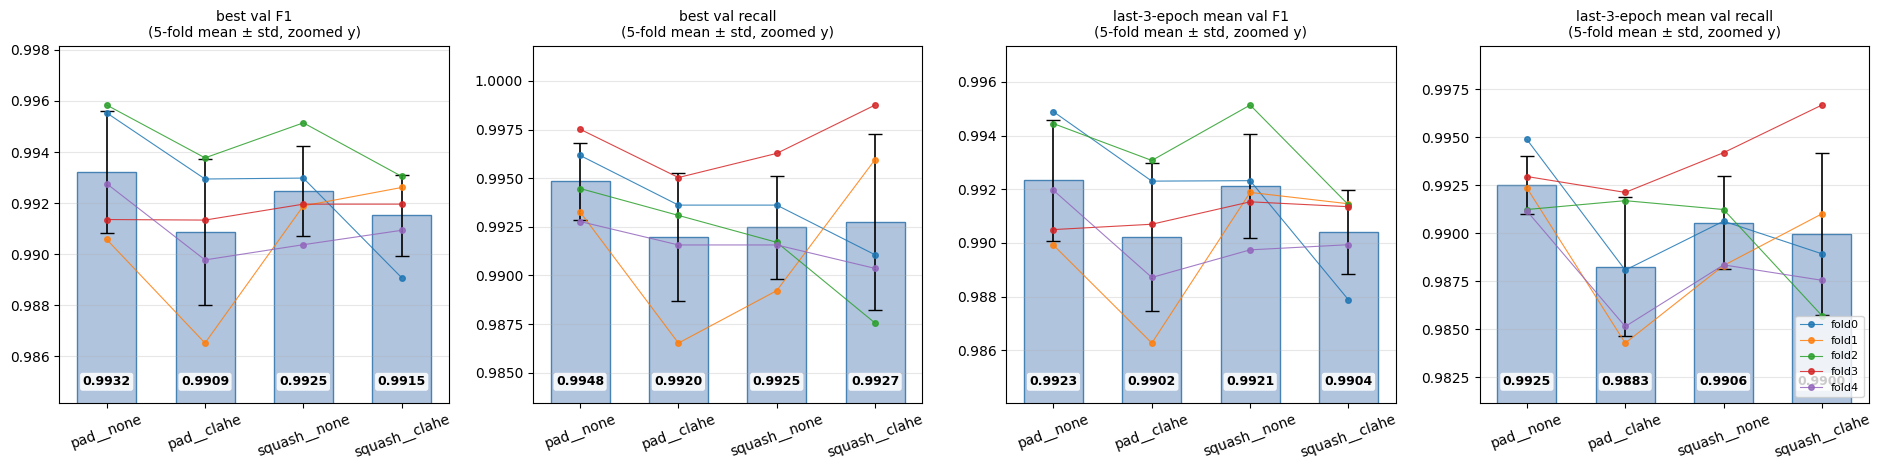

In [42]:
# ---------- 5-5. 전처리별 막대그래프: 막대 = 5-fold 평균, 오차막대 = std, 점/선 = fold별 값 ----------
# 같은 fold끼리 선으로 이어 짝 구조를 보이게 한다: 선들이 같은 방향으로 기울면 fold가 달라도 전처리 효과가 일관된다는 뜻이다.
# 차이가 작아 y축은 0부터가 아니라 값 범위로 확대한다 (막대 높이 비율로 읽지 말고 눈금 값으로 읽는다).
x = np.arange(len(KF_VARIANTS))
fold_colors = plt.cm.tab10(np.arange(N_FOLDS))
fig, axes = plt.subplots(1, len(KF_METRICS), figsize=(19, 4.8))
for ax, (m, title) in zip(axes, KF_METRICS):
    t = fold_table(m)
    folds = t.drop(columns=["mean", "std"])
    ax.bar(x, t["mean"], yerr=t["std"], capsize=5, width=0.6, color="lightsteelblue", edgecolor="steelblue",
           error_kw={"lw": 1.2})
    for xi, mu in enumerate(t["mean"]):   # 평균 수치: fold 선과 겹치지 않게 막대 안쪽 아래(축 높이 4%)에 고정
        ax.text(xi, 0.04, f"{mu:.4f}", transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                fontsize=9, fontweight="bold", bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": "none", "alpha": 0.85})
    for j, col in enumerate(folds.columns):
        ax.plot(x, folds[col], marker="o", ms=4, lw=0.8, alpha=0.85, color=fold_colors[j], label=col)
    lo = np.nanmin([folds.min().min(), (t["mean"] - t["std"]).min()])
    hi = np.nanmax([folds.max().max(), (t["mean"] + t["std"]).max()])
    pad = max((hi - lo) * 0.25, 0.001)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xticks(x, KF_VARIANTS, rotation=20)
    ax.set_title(f"{title}\n(5-fold mean ± std, zoomed y)", fontsize=10)
    ax.grid(alpha=0.3, axis="y")
axes[-1].legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()


In [39]:
# ---------- 5-6. 짝 비교 + 판정: fold마다 (B - A)를 계산해 방향의 일관성과 크기를 본다 ----------
# 주효과: 다른 축 두 수준의 평균끼리 비교 (예: squash-pad = (squash__none + squash__clahe)/2 - (pad__none + pad__clahe)/2)
# 수준별: 다른 축을 한 수준에 고정한 비교 (예: squash-pad | clahe). 주효과와 방향이 다르면 두 축이 상호작용한다는 신호다.
# 판정(5장 마크다운): fold 5개가 모두 같은 방향 + |평균 차이| > 차이의 표준편차 -> 효과 있음, 그 외 -> 차이 없음.
from IPython.display import Markdown

COMPARISONS = {  # 이름: (B 변형들, A 변형들) -> 차이 = mean(B) - mean(A)
    "squash-pad (주효과)": (["squash__none", "squash__clahe"], ["pad__none", "pad__clahe"]),
    "squash-pad | none": (["squash__none"], ["pad__none"]),
    "squash-pad | clahe": (["squash__clahe"], ["pad__clahe"]),
    "clahe-none (주효과)": (["pad__clahe", "squash__clahe"], ["pad__none", "squash__none"]),
    "clahe-none | pad": (["pad__clahe"], ["pad__none"]),
    "clahe-none | squash": (["squash__clahe"], ["squash__none"]),
}
JUDGE_METRICS = [("last3_f1", "last-3-epoch mean val F1"), ("best_f1", "best val F1"),
                 ("last3_recall", "last-3-epoch mean val recall"), ("best_recall", "best val recall"),]


def paired_comparison(metric: str) -> pd.DataFrame:
    w = kf_runs.pivot(index="fold", columns="variant", values=metric)
    one = KF_ONE_SAMPLE["recall" if "recall" in metric else "f1"]
    rows = []
    for name, (b, a) in COMPARISONS.items():
        d = (w[b].mean(axis=1) - w[a].mean(axis=1)).dropna()
        n_pos, n_neg = int((d > 0).sum()), int((d < 0).sum())
        mean, std = d.mean(), d.std(ddof=1)
        if len(d) < N_FOLDS:
            verdict = f"미완료 ({len(d)}/{N_FOLDS} fold)"
        elif max(n_pos, n_neg) == N_FOLDS and abs(mean) > std:
            verdict = f"효과 있음 ({name.split()[0].split('-')[0 if mean > 0 else 1]} 우세)"
        else:
            verdict = "차이 없음"
        rows.append({"비교": name, **{f"fold{k}": d.get(k, np.nan) for k in range(N_FOLDS)},
                     "+ fold 수": n_pos, "- fold 수": n_neg, "평균 차이": mean, "표준편차": std,
                     "|평균|/std": abs(mean) / std if std > 0 else np.nan, "평균/1장": mean / one, "판정": verdict})
    return pd.DataFrame(rows).set_index("비교")


display(Markdown(f"""
| 컬럼 | 의미 |
|--|--|
| fold0~4 | 그 fold에서의 차이 (B − A). 양수면 앞쪽(B, 예: squash) 지표가 높다 |
| + / − fold 수 | 차이가 양수 / 음수였던 fold 수. 둘 중 하나가 {N_FOLDS}이면 모든 fold에서 같은 방향 |
| 평균 차이, 표준편차 | fold 5개 차이의 평균과 표본 표준편차 |
| \\|평균\\|/std | 1보다 크면 평균 차이가 fold 간 흔들림보다 크다 |
| 평균/1장 | 평균 차이를 val 1장 오분류 크기(F1 {KF_ONE_SAMPLE['f1']:.4f}, recall {KF_ONE_SAMPLE['recall']:.4f})로 나눈 값. 1 미만이면 평균적으로 1장도 안 되는 차이 |
| 판정 | 모든 fold 같은 방향 + \\|평균\\| > std -> 효과 있음, 그 외 -> 차이 없음 |
"""))
kf_verdicts = {}
for m, title in JUDGE_METRICS:
    display(Markdown(f"#### {title}"))
    kf_verdicts[m] = paired_comparison(m)
    display(kf_verdicts[m].round(4))

# 최종 전처리 선택에 쓸 요약: 주효과 판정 + 전처리별 5-fold 평균 (기준 지표 = last-3-epoch mean val F1, last-3-epoch mean val recall)
for m, title in [("last3_f1", "last-3-epoch mean val F1"), ("last3_recall", "last-3-epoch mean val recall")]:
    print(f"주효과 판정 ({title}):")
    for name in ["squash-pad (주효과)", "clahe-none (주효과)"]:
        r = kf_verdicts[m].loc[name]
        print(f"  {name}: {r['판정']} | 평균 {r['평균 차이']:+.4f} ± {r['표준편차']:.4f}, "
              f"+{int(r['+ fold 수'])} / -{int(r['- fold 수'])} fold, 1장 대비 {r['평균/1장']:+.2f}")
    t = fold_table(m).sort_values("mean", ascending=False)
    print(f"전처리별 {title} (5-fold 평균 ± std, 높은 순):")
    for v, r in t.iterrows():
        print(f"  {v:14s} {r['mean']:.4f} ± {r['std']:.4f}")
    print()



| 컬럼 | 의미 |
|--|--|
| fold0~4 | 그 fold에서의 차이 (B − A). 양수면 앞쪽(B, 예: squash) 지표가 높다 |
| + / − fold 수 | 차이가 양수 / 음수였던 fold 수. 둘 중 하나가 5이면 모든 fold에서 같은 방향 |
| 평균 차이, 표준편차 | fold 5개 차이의 평균과 표본 표준편차 |
| \|평균\|/std | 1보다 크면 평균 차이가 fold 간 흔들림보다 크다 |
| 평균/1장 | 평균 차이를 val 1장 오분류 크기(F1 0.0006, recall 0.0013)로 나눈 값. 1 미만이면 평균적으로 1장도 안 되는 차이 |
| 판정 | 모든 fold 같은 방향 + \|평균\| > std -> 효과 있음, 그 외 -> 차이 없음 |


#### last-3-epoch mean val F1

,fold0,fold1,fold2,fold3,fold4,+ fold 수,- fold 수,평균 차이,표준편차,|평균|/std,평균/1장,판정
비교,,,,,,,,,,,,
squash-pad (주효과),-0.0035,0.0036,-0.0005,0.0008,-0.0005,2,3,-0.0000,0.0026,0.0042,-0.0167,차이 없음
squash-pad | none,-0.0026,0.0020,0.0007,0.0010,-0.0022,3,2,-0.0002,0.0020,0.1070,-0.3388,차이 없음
squash-pad | clahe,-0.0044,0.0052,-0.0017,0.0007,0.0012,3,2,0.0002,0.0036,0.0552,0.3054,차이 없음
clahe-none (주효과),-0.0035,-0.0020,-0.0025,0.0000,-0.0015,1,4,-0.0019,0.0013,1.4729,-2.9794,차이 없음
clahe-none | pad,-0.0026,-0.0036,-0.0014,0.0002,-0.0032,1,4,-0.0021,0.0016,1.3649,-3.3014,차이 없음
clahe-none | squash,-0.0044,-0.0004,-0.0037,-0.0002,0.0002,1,4,-0.0017,0.0022,0.7848,-2.6573,차이 없음


#### best val F1

,fold0,fold1,fold2,fold3,fold4,+ fold 수,- fold 수,평균 차이,표준편차,|평균|/std,평균/1장,판정
비교,,,,,,,,,,,,
squash-pad (주효과),-0.0032,0.0037,-0.0007,0.0006,-0.0006,2,3,-0.0000,0.0025,0.0175,-0.0680,차이 없음
squash-pad | none,-0.0026,0.0013,-0.0007,0.0006,-0.0024,2,3,-0.0007,0.0017,0.4295,-1.1536,차이 없음
squash-pad | clahe,-0.0039,0.0061,-0.0007,0.0006,0.0012,3,2,0.0007,0.0036,0.1820,1.0175,차이 없음
clahe-none (주효과),-0.0032,-0.0017,-0.0021,-0.0000,-0.0012,0,5,-0.0016,0.0012,1.3877,-2.5452,효과 있음 (none 우세)
clahe-none | pad,-0.0026,-0.0041,-0.0021,-0.0000,-0.0030,0,5,-0.0023,0.0015,1.5737,-3.6307,효과 있음 (none 우세)
clahe-none | squash,-0.0039,0.0007,-0.0021,0.0000,0.0006,2,2,-0.0009,0.0020,0.4712,-1.4596,차이 없음


#### last-3-epoch mean val recall

,fold0,fold1,fold2,fold3,fold4,+ fold 수,- fold 수,평균 차이,표준편차,|평균|/std,평균/1장,판정
비교,,,,,,,,,,,,
squash-pad (주효과),-0.0017,0.0013,-0.0030,0.0029,-0.0002,2,3,-0.0001,0.0023,0.0557,-0.1013,차이 없음
squash-pad | none,-0.0043,-0.0040,0.0000,0.0012,-0.0028,1,3,-0.0020,0.0025,0.7986,-1.5289,차이 없음
squash-pad | clahe,0.0009,0.0067,-0.0060,0.0046,0.0024,4,1,0.0017,0.0048,0.3533,1.3262,차이 없음
clahe-none (주효과),-0.0043,-0.0027,-0.0025,0.0008,-0.0034,1,4,-0.0024,0.0019,1.2469,-1.8704,차이 없음
clahe-none | pad,-0.0068,-0.0081,0.0005,-0.0008,-0.0060,1,4,-0.0043,0.0038,1.1150,-3.2980,차이 없음
clahe-none | squash,-0.0017,0.0027,-0.0055,0.0025,-0.0008,2,3,-0.0006,0.0034,0.1687,-0.4429,차이 없음


#### best val recall

,fold0,fold1,fold2,fold3,fold4,+ fold 수,- fold 수,평균 차이,표준편차,|평균|/std,평균/1장,판정
비교,,,,,,,,,,,,
squash-pad (주효과),-0.0026,0.0027,-0.0041,0.0012,-0.0012,2,3,-0.0008,0.0028,0.2860,-0.6152,차이 없음
squash-pad | none,-0.0026,-0.0040,-0.0028,-0.0012,-0.0012,0,5,-0.0024,0.0012,1.9929,-1.8297,효과 있음 (pad 우세)
squash-pad | clahe,-0.0026,0.0094,-0.0055,0.0037,-0.0012,2,3,0.0008,0.0059,0.1315,0.5994,차이 없음
clahe-none (주효과),-0.0026,0.0000,-0.0028,0.0000,-0.0012,0,3,-0.0013,0.0013,0.9787,-1.0109,차이 없음
clahe-none | pad,-0.0026,-0.0067,-0.0014,-0.0025,-0.0012,0,5,-0.0029,0.0022,1.2786,-2.2254,효과 있음 (none 우세)
clahe-none | squash,-0.0026,0.0067,-0.0041,0.0025,-0.0012,2,3,0.0003,0.0044,0.0601,0.2036,차이 없음


주효과 판정 (last-3-epoch mean val F1):
  squash-pad (주효과): 차이 없음 | 평균 -0.0000 ± 0.0026, +2 / -3 fold, 1장 대비 -0.02
  clahe-none (주효과): 차이 없음 | 평균 -0.0019 ± 0.0013, +1 / -4 fold, 1장 대비 -2.98
전처리별 last-3-epoch mean val F1 (5-fold 평균 ± std, 높은 순):
  pad__none      0.9923 ± 0.0023
  squash__none   0.9921 ± 0.0019
  squash__clahe  0.9904 ± 0.0016
  pad__clahe     0.9902 ± 0.0028

주효과 판정 (last-3-epoch mean val recall):
  squash-pad (주효과): 차이 없음 | 평균 -0.0001 ± 0.0023, +2 / -3 fold, 1장 대비 -0.10
  clahe-none (주효과): 차이 없음 | 평균 -0.0024 ± 0.0019, +1 / -4 fold, 1장 대비 -1.87
전처리별 last-3-epoch mean val recall (5-fold 평균 ± std, 높은 순):
  pad__none      0.9925 ± 0.0015
  squash__none   0.9906 ± 0.0024
  squash__clahe  0.9900 ± 0.0042
  pad__clahe     0.9883 ± 0.0036



## 5.1. Cross Validation 결과 해석: squash VS pad, clahe vs none 결과에 유의미한 영향을 준 설정이 있을까?

- **관찰**
    - 막대 그래프만 봤을 때, last 3 epoch mean f1, last 3 epoch mean recall 두 지표 모두 **`pad__none`이 1위**이다. 
        - f1 기준: 2위, 3위, 4위와의 차이는 0.0002, 0.0019, 0.0021로 매우 근소하다. 이는 validation을 약 0.3~3.3장 더 맞춘 차이다. (f1: fold당 validation 약 1,046장 기준, 1장을 더 맞추거나 틀리면 약 0.0006 차이)
            - pad__none      0.9923 ± 0.0023
            - squash__none   0.9921 ± 0.0019
            - squash__clahe  0.9904 ± 0.0016
            - pad__clahe     0.9902 ± 0.0028
        - recall 기준: 2위, 3위, 4위와의 차이는 0.0019, 0.0025, 0.0042로 매우 근소하다. 이는 validation을 약 1.5~3.2장 더 맞춘 차이다. (recall: 1장을 더 맞추거나 틀리면 약 0.0013 차이)
            - pad__none      0.9925 ± 0.0015
            - squash__none   0.9906 ± 0.0024
            - squash__clahe  0.9900 ± 0.0042
            - pad__clahe     0.9883 ± 0.0036
        - 표준편차(± 뒤의 값)는 5개 fold 사이에서 점수가 흔들린 정도다. 1위와 4위의 차이가 대부분 이 흔들림과 비슷하거나 작다. 

    - **pad vs squash: 차이 없다.**
        - last 3 epoch mean f1을 기준으로, fold마다 (squash 점수 - pad 점수)를 구했을 때 그 평균은 -0.0000 ± 0.0026이다. 
            - 평균은 사실상 0이고, 표준편차가 평균보다 훨씬 크다. 
            - pad가 우세한 fold는 5개 중 3개, squash가 우세한 fold는 2개로 방향이 섞여 있다. 
            - validation 0.02장 더 맞춘 차이다. 
        - last 3 epoch mean recall을 기준으로, 같은 방식으로 구한 평균 차이는 -0.0001 ± 0.0023이다. 
            - pad가 우세한 fold는 5개 중 3개로, 역시 방향이 섞여 있다. 
            - validation 0.1장 더 맞춘 차이다.
        - clahe가 적용된 경우에는 squash가 근소 우세했고, clahe가 적용되지 않은 경우에는 pad가 근소 우세했다. 하지만 이 차이도 매우 작다. 
            - f1 기준 약 0.0002 차이, recall 기준 약 0.002 차이. 
            - 보조 지표인 best val recall에서는 clahe를 적용하지 않았을 때 5개 fold 모두 pad가 우세해 판정 기준을 통과했다(평균 차이 -0.0024, validation 약 1.8장). 다만 주 지표(last 3 epoch mean)에서는 통과하지 못했으므로 결론을 바꿀 근거로 보지 않는다. 

    - **clahe vs none: 판정 기준으로는 차이 없음이지만, 경계선에 있다. 경향은 none(CLAHE 미적용)이 우세하다.**
        - last 3 epoch mean f1을 기준으로, fold마다 (clahe 점수 - none 점수)를 구했을 때 그 평균은 -0.0019 ± 0.0013이다.
            - none이 근소 우세
            - none이 우세한 횟수는 5fold 중 4회다. 
            - validation 2.98장 더 맞춘 차이다.
        - last 3 epoch mean recall을 기준으로, 같은 방식으로 구한 평균 차이는 -0.0024 ± 0.0019다.
            - none이 근소 우세
            - none이 우세한 횟수는 5fold 중 4회다. 
            - validation 1.87장 더 맞춘 차이다. 
        - 판정 기준은 "5개 fold가 모두 같은 방향이고, 평균 차이의 크기가 표준편차보다 크다"였다. 
            - 두 지표 모두 평균 차이의 크기는 표준편차보다 크다(평균 차이 / 표준편차 = f1 1.47, recall 1.25). 
            - 하지만 fold3 하나에서 차이가 거의 0이거나(f1) 아주 작은 양수(recall +0.0008)여서 "5개 fold 모두 같은 방향" 조건을 넘지 못했다. 
            - 실제로 보조 지표인 best val F1에서는 fold3의 차이가 아주 작은 음수로 나와 5개 fold 모두 none이 우세했고, "효과 있음"으로 판정되었다. 즉, 판정을 가른 것은 사실상 0에 가까운 fold 하나다. 
        - 주로 pad와 조합되었을 때 clahe의 성능이 안좋았다. 
            - pad에 고정하고 clahe를 비교하면 4개 지표 모두에서 5개 fold 중 4~5개가 none 우세였다. 
            - squash에 고정하고 비교하면 fold마다 방향이 섞였다. 즉, CLAHE의 효과는 사이즈를 맞추는 방식에 따라 달라질 수 있다. 

    - **4장 결과와 비교: 4.3에서 본 차이는 재현되지 않았다.**
        - 4.3에서는 한 번의 train/validation 분할에서 "partial, full에서는 squash가 pad보다 좋거나 비슷하다"고 보았다. 
        - 5-fold에서는 squash와 pad의 차이가 0에 가깝게 나왔다. 따라서 4.3에서 본 squash의 근소 우위는 분할 하나에서 생긴 우연(노이즈)이었을 가능성이 높다. 

- **결론**
    - 평균만 보면 F1과 recall 모두 `pad__none`이 1위이지만, **어떤 전처리도 확실한 이득을 보이지 않는다**. 
    - **pad와 squash는 차이가 없다.** 
        - 1장에서 세운 EDA 가설, "클래스 별로 이미지 크기와 종횡비가 다르기 때문에 종횡비를 유지하느냐(pad) 무시하느냐(squash)가 성능에 영향을 줄 것이다"는 EfficientNet-B0 + Full Fine-Tuning에서는 지지되지 않았다. 
    - **CLAHE는 도움이 되지 않고, 오히려 약간 손해일 가능성이 있다.**
        - none과 clahe 비교에서, recall과 f1 관점 모두 5fold 중 4회가 none이 우세했다. 
        - 다만 미리 정한 판정 기준은 통과하지 못했으므로 "CLAHE가 성능을 떨어뜨린다"고 단정할 수는 없다. 
    - **pad, squash는 별 차이가 없고, clahe는 쓸 근거가 없다.** CLAHE는 성능 이득이 없으면서 전처리 단계만 하나 늘리므로, 쓰지 않는 쪽을 택한다.
    

- **한계**
    - **이 결론은 EfficientNet-B0 + Full Fine-Tuning 한 조합에만 해당한다.** 
        - 다른 모델이나 학습 방법(특히 Frozen)에서도 전처리의 영향이 없다고 말할 수는 없다. 
        - 실제로 6장의 test에서 ResNet50 + Frozen은 전처리에 따라 결과가 크게 달랐다(폐렴을 정상으로 놓친 장수: pad__none 54장, squash__clahe 12장). 
        - 그리고 EfficientNet-B0 + Full이라는 기준 조합 자체를 4장의 validation 결과를 보고 골랐다. 
    - **판정 기준은 정식 통계 검정이 아니다.** 
        - fold 5개에서 "모두 같은 방향 + 평균 차이 > 표준편차"라는 규칙을 직접 정해서 썼다. fold가 5개뿐이라, 위의 clahe 결과처럼 0에 가까운 fold 하나에 판정이 바뀔 수 있다. 
        - 5개 fold는 서로 학습 데이터의 대부분(약 75%)을 공유한다. 따라서 fold들이 완전히 독립적인 실험이 아니고, 표준편차가 실제보다 작게 나왔을 수 있다. 
        - 4개 지표 x 6개 비교 = 24번 판정했다. 판정을 여러 번 하면 실제 효과가 없어도 몇 개는 우연히 "효과 있음"으로 나올 수 있다. 그래서 결론은 미리 정한 주 지표(last 3 epoch mean f1, recall)로만 내렸다. 
    - **seed가 하나, 학습은 10 에폭이다.** 4장과 같은 설정을 유지했기 때문에, 학습을 더 길게 하거나 seed를 바꿨을 때도 같은 결론이 나오는지는 확인하지 못했다. 
    - **전처리를 바꾼 폭이 좁다.** CLAHE는 파라미터 한 가지만, 사이즈 맞추기는 pad와 squash 두 가지만 비교했다. 다른 CLAHE 강도나 crop 같은 방식에서는 결과가 다를 수 있다. 
    - **validation이 이미 천장에 가깝다.** 모든 전처리의 f1, recall이 0.99 근처라서, 전처리의 차이가 있더라도 validation 몇 장 수준으로만 드러난다. 6장에서 보듯 test에서는 성능이 크게 떨어지므로, validation에서 차이가 없다는 것이 test에서도 차이가 없다는 뜻은 아니다. 

# 6. Test 평가
- 목적: 
    - ResNet, DenseNet, EfficientNet 세 모델 각각에서 가장 성능이 좋았던 모델을 찾는다.
    - Frozen, Partial, Full Fine-tuning 중 가장 성능이 좋았던 학습 방법을 찾는다.

- 시각화:
    - ResNet, DenseNet, EfficientNet 세 모델 각각에 대해서 Frozen, Partial, Full Fine-tuning 세 가지 학습 방법 각각에 대해 Test 데이터로 예측한다.
        - bar chart를 사용한다. 각각의 막대 위에는 값이 보여야 한다. 
        - 총 세 개의 막대그래프를 그린다. 최종 loss와 recall, f1을 막대그래프로 확인한다. 
    - Grad-CAM으로 세 모델 x 네 학습 방법이 각각 어딜 보는 지 시각화한다. 

- test 결과는 csv에 캐싱한다. 이 셀을 다시 돌려도 재 예측을 하지 않도록 한다. 
- 데이터셋은 cross-validation last-3 epoch recall 기준으로 모델 성능을 가장 흔들지 않았던 하나로 고정한다. 

In [45]:
# ---------- 6-1. Test에 쓸 전처리 고정: 5장 K-Fold에서 fold 간 표준편차가 가장 작았던 전처리 ----------
# 5-4의 kf_runs / fold_table을 쓴다 (학습 없이 0장 + 1장 + 2장 + 5-1 + 5-2 + 5-4 셀만 실행해도 된다).
# 기준 지표는 5장 판정과 같은 last-3-epoch mean val F1. 다른 지표의 std도 함께 출력해 기준에 따라 결과가 바뀌는지 확인한다.
TEST_STABILITY_METRIC = "last3_recall" 
kf_std = pd.DataFrame({title: fold_table(m)["std"] for m, title in KF_METRICS}).rename_axis("variant")
display(kf_std.round(4).style.highlight_min(axis=0, color="lightgreen"))
TEST_VARIANT = fold_table(TEST_STABILITY_METRIC)["std"].idxmin()
print(f"Test 전처리: {TEST_VARIANT} (5-fold {TEST_STABILITY_METRIC} std 최소)")

# test 1장 오분류가 지표를 움직이는 크기 (막대그래프의 차이를 읽는 기준)
test_rows = all_df[all_df["split"] == "test"]
n_test_pos = int((test_rows["label"] == POS_LABEL).sum())
TEST_ONE_SAMPLE = {"f1": 1 / (2 * n_test_pos), "recall": 1 / n_test_pos}
print(f"test {len(test_rows)}장 (NORMAL {len(test_rows) - n_test_pos}, PNEUMONIA {n_test_pos}) "
      f"-> 1장 오분류: F1 약 {TEST_ONE_SAMPLE['f1']:.4f}, recall 약 {TEST_ONE_SAMPLE['recall']:.4f}")


,best val F1,best val recall,last-3-epoch mean val F1,last-3-epoch mean val recall
variant,,,,
pad__none,0.002400,0.002000,0.002300,0.001500
pad__clahe,0.002900,0.003300,0.002800,0.003600
squash__none,0.001800,0.002600,0.001900,0.002400
squash__clahe,0.001600,0.004500,0.001600,0.004200


Test 전처리: pad__none (5-fold last3_recall std 최소)
test 618장 (NORMAL 231, PNEUMONIA 387) -> 1장 오분류: F1 약 0.0013, recall 약 0.0026


In [46]:
# ---------- 6-2. Test 예측: 3모델 x 3모드 best checkpoint -> results/test/test_metrics.csv에 캐싱 ----------
# CSV에 이미 있는 run은 다시 예측하지 않는다 (Run All / 재실행 안전). run 하나가 끝날 때마다 1행씩 추가한다.
# 가중치는 3장 학습의 val F1 best checkpoint(results/checkpoints/{run}_best.pt)를 그대로 쓴다.
TEST_DIR = RESULT_DIR / "test"
TEST_DIR.mkdir(parents=True, exist_ok=True)
TEST_METRICS_PATH = TEST_DIR / "test_metrics.csv"
TEST_RUNS = [run_name_of(a, m, TEST_VARIANT) for a in ARCHS for m in MODES]


def load_best_model(arch: str, mode: str, variant: str):
    """build_model 구조에 best 가중치를 올려 eval 모드로 반환한다 (사전학습 가중치는 덮어쓰므로 받지 않는다)."""
    ck = torch.load(CKPT_DIR / f"{run_name_of(arch, mode, variant)}_best.pt", map_location="cpu", weights_only=False)
    model = build_model(arch, mode, pretrained=False)
    model.load_state_dict(ck["state_dict"])
    return model.to(DEVICE).eval(), ck


cached = set(pd.read_csv(TEST_METRICS_PATH)["run"]) if TEST_METRICS_PATH.exists() else set()
todo = [r for r in TEST_RUNS if r not in cached]
print(f"캐시 {len(TEST_RUNS) - len(todo)} / {len(TEST_RUNS)} run, 예측할 run {len(todo)}개")
if todo:
    test_loader = make_loaders(TEST_VARIANT)["test"]
    for run in todo:
        arch, mode, variant = run.split("__", 2)
        model, ck = load_best_model(arch, mode, variant)
        te, _, _ = evaluate(model, test_loader, nn.CrossEntropyLoss())
        tn, fp, fn, tp = te.pop("confusion_matrix").ravel().tolist()
        row = {"run": run, "arch": arch, "mode": mode, "variant": variant, "best_epoch": ck["epoch"],
               "n_test": len(test_loader.indices), **{f"test_{k}": v for k, v in te.items()},
               "test_tn": tn, "test_fp": fp, "test_fn": fn, "test_tp": tp,
               "evaluated_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}
        pd.DataFrame([row]).to_csv(TEST_METRICS_PATH, mode="a", header=not TEST_METRICS_PATH.exists(), index=False)
        print(f"[{run}] loss {te['loss']:.4f} recall {te['recall']:.4f} f1 {te['f1']:.4f}")
        del model

test_res = (pd.read_csv(TEST_METRICS_PATH).query("run in @TEST_RUNS").drop_duplicates("run", keep="last")
            .set_index("run").loc[TEST_RUNS].reset_index())
display(test_res.set_index(["arch", "mode"])[["best_epoch", "test_loss", "test_accuracy", "test_precision", "test_recall",
                                             "test_f1", "test_roc_auc", "test_tn", "test_fp", "test_fn", "test_tp"]].round(4))


캐시 0 / 9 run, 예측할 run 9개
[resnet50__frozen__pad__none] loss 0.3505 recall 0.8605 f1 0.8892
[resnet50__partial__pad__none] loss 0.5710 recall 0.9974 f1 0.9008
[resnet50__full__pad__none] loss 0.8355 recall 0.9948 f1 0.8912
[densenet121__frozen__pad__none] loss 0.3744 recall 0.9819 f1 0.8889
[densenet121__partial__pad__none] loss 0.9982 recall 0.9974 f1 0.8783
[densenet121__full__pad__none] loss 0.7260 recall 0.9948 f1 0.8740
[efficientnet_b0__frozen__pad__none] loss 0.4079 recall 0.9638 f1 0.8705
[efficientnet_b0__partial__pad__none] loss 0.6425 recall 0.9948 f1 0.8851
[efficientnet_b0__full__pad__none] loss 0.6180 recall 0.9974 f1 0.8843


best_epoch  test_loss  test_accuracy  test_precision  \
arch            mode                                                            
resnet50        frozen            8     0.3505         0.8657          0.9199   
                partial           5     0.5710         0.8625          0.8213   
                full             10     0.8355         0.8479          0.8071   
densenet121     frozen            8     0.3744         0.8463          0.8120   
                partial          10     0.9982         0.8269          0.7846   
                full              1     0.7260         0.8204          0.7794   
efficientnet_b0 frozen            5     0.4079         0.8204          0.7936   
                partial           5     0.6425         0.8382          0.7971   
                full              4     0.6180         0.8366          0.7942   

                         test_recall  test_f1  test_roc_auc  test_tn  test_fp  \
arch            mode                                                            
resnet50        frozen        0.8605   0.8892        0.9342      202       29   
                partial       0.9974   0.9008        0.9825      147       84   
                full          0.9948   0.8912        0.9703      139       92   
densenet121     frozen        0.9819   0.8889        0.9535      143       88   
                partial       0.9974   0.8783        0.9520      125      106   
                full          0.9948   0.8740        0.9564      122      109   
efficientnet_b0 frozen        0.9638   0.8705        0.9337      134       97   
                partial       0.9948   0.8851        0.9649      133       98   
                full          0.9974   0.8843        0.9749      131      100   

                         test_fn  test_tp  
arch            mode                       
resnet50        frozen        54      333  
                partial        1      386  
                full           2      385  
densenet121     frozen         7      380  
                partial        1      386  
                full           2      385  
efficientnet_b0 frozen        14      373  
                partial        2      385  
                full           1      386

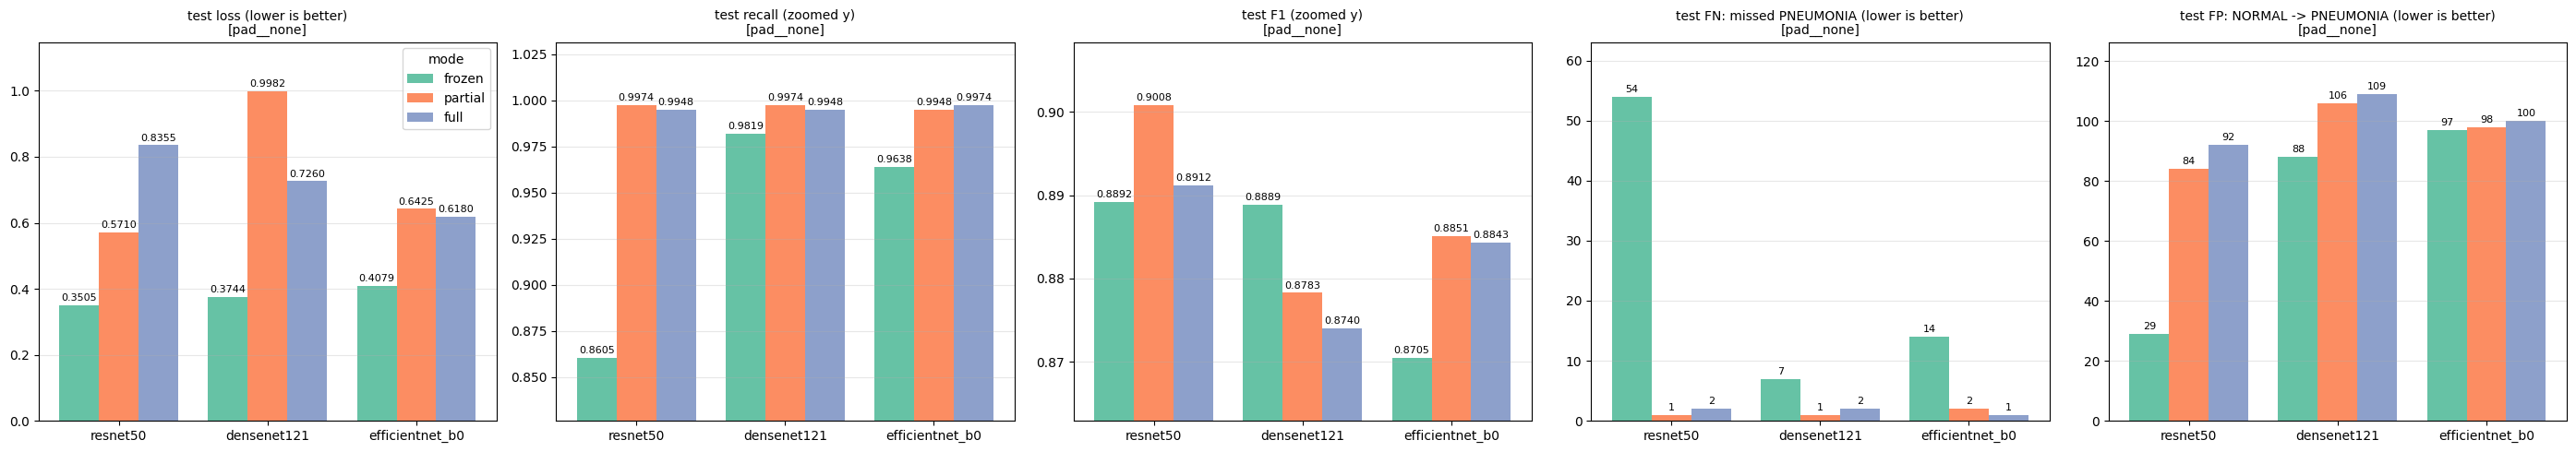

test 1장 오분류 = recall 0.0026, F1 약 0.0013

[recall 우선 (FN -> FP -> F1)] 모델별 가장 성능이 좋았던 학습 방법:
  resnet50         partial  recall 0.9974 (FN 1) | FP 84 | F1 0.9008 | loss 0.5710
  densenet121      partial  recall 0.9974 (FN 1) | FP 106 | F1 0.8783 | loss 0.9982
  efficientnet_b0  full     recall 0.9974 (FN 1) | FP 100 | F1 0.8843 | loss 0.6180
  전체 최고: resnet50         partial  recall 0.9974 (FN 1) | FP 84 | F1 0.9008 | loss 0.5710

[F1 기준 (F1 -> recall -> loss)] 모델별 가장 성능이 좋았던 학습 방법:
  resnet50         partial  recall 0.9974 (FN 1) | FP 84 | F1 0.9008 | loss 0.5710
  densenet121      frozen   recall 0.9819 (FN 7) | FP 88 | F1 0.8889 | loss 0.3744
  efficientnet_b0  partial  recall 0.9948 (FN 2) | FP 98 | F1 0.8851 | loss 0.6425
  전체 최고: resnet50         partial  recall 0.9974 (FN 1) | FP 84 | F1 0.9008 | loss 0.5710


,test_loss,test_recall,test_f1,test_fn,test_fp,1등 모델 수: recall 우선,1등 모델 수: F1 기준
mode,,,,,,,
frozen,0.3776,0.9354,0.8829,25.0000,71.3333,0,1
partial,0.7373,0.9966,0.8880,1.3333,96.0000,2,2
full,0.7265,0.9957,0.8832,1.6667,100.3333,1,0


In [47]:
# ---------- 6-3. Test 막대그래프 (loss / recall / F1 / FN / FP) + 모델별 / 학습 방법별 최고 성능 ----------
# x축 = 모델, 막대 색 = 학습 방법. recall / F1은 차이가 작아 y축을 값 범위로 확대한다 (막대 위 값으로 읽는다).
# FN(놓친 PNEUMONIA)과 FP(PNEUMONIA로 잘못 본 NORMAL)를 장 수로 함께 그려 recall을 얻은 대가를 보이게 한다.
TEST_PLOT_METRICS = [("test_loss", "test loss (lower is better)"), ("test_recall", "test recall"), ("test_f1", "test F1"),
                     ("test_fn", "test FN: missed PNEUMONIA (lower is better)"),
                     ("test_fp", "test FP: NORMAL -> PNEUMONIA (lower is better)")]
mode_colors = dict(zip(MODES, plt.cm.Set2(np.arange(len(MODES)))))
x = np.arange(len(ARCHS))
w = 0.8 / len(MODES)
fig, axes = plt.subplots(1, len(TEST_PLOT_METRICS), figsize=(5.6 * len(TEST_PLOT_METRICS), 5))
for ax, (m, title) in zip(axes, TEST_PLOT_METRICS):
    t = test_res.pivot(index="arch", columns="mode", values=m).reindex(index=ARCHS, columns=MODES)
    is_count = m in ("test_fn", "test_fp")
    for j, mode in enumerate(MODES):
        bars = ax.bar(x + (j - (len(MODES) - 1) / 2) * w, t[mode], w, label=mode, color=mode_colors[mode])
        ax.bar_label(bars, fmt="%d" if is_count else "%.4f", fontsize=8, padding=2)
    if m == "test_loss" or is_count:
        ax.set_ylim(0, t.max().max() * 1.15 + (1 if is_count else 0))
    else:
        lo, hi = t.min().min(), t.max().max()
        pad = max((hi - lo) * 0.25, 0.002)
        ax.set_ylim(lo - pad, hi + pad)
        title += " (zoomed y)"
    ax.set_xticks(x, ARCHS)
    ax.set_title(f"{title}\n[{TEST_VARIANT}]", fontsize=10)
    ax.grid(alpha=0.3, axis="y")
axes[0].legend(title="mode")
fig.tight_layout()
plt.show()

# 순위 규칙: recall 우선. recall만으로는 전부 PNEUMONIA로 예측해도 1.0이 되므로 동률(같은 FN 장 수)이면 FP가 적은 쪽.
# test 장 수가 모든 run에서 같으므로 FN 오름차순 = recall 내림차순이고, 1장 단위로 비교된다.
RANKINGS = {  # 이름: (정렬 컬럼, 오름차순 여부)
    "recall 우선 (FN -> FP -> F1)": (["test_fn", "test_fp", "test_f1"], [True, True, False]),
    "F1 기준 (F1 -> recall -> loss)": (["test_f1", "test_recall", "test_loss"], [False, False, True]),
}
ranked = {name: test_res.sort_values(cols, ascending=asc) for name, (cols, asc) in RANKINGS.items()}


def describe(r) -> str:
    return (f"{r['arch']:16s} {r['mode']:8s} recall {r['test_recall']:.4f} (FN {int(r['test_fn'])}) | "
            f"FP {int(r['test_fp'])} | F1 {r['test_f1']:.4f} | loss {r['test_loss']:.4f}")


print(f"test 1장 오분류 = recall {TEST_ONE_SAMPLE['recall']:.4f}, F1 약 {TEST_ONE_SAMPLE['f1']:.4f}")
for name, rk in ranked.items():
    print(f"\n[{name}] 모델별 가장 성능이 좋았던 학습 방법:")
    for arch in ARCHS:
        print("  " + describe(rk[rk["arch"] == arch].iloc[0]))
    print("  전체 최고: " + describe(rk.iloc[0]))

# 학습 방법별: 세 모델 평균 + 기준별로 모델마다 1등을 한 횟수
by_mode = test_res.groupby("mode")[["test_loss", "test_recall", "test_f1", "test_fn", "test_fp"]].mean().reindex(MODES)
for name, rk in ranked.items():
    by_mode[f"1등 모델 수: {name.split(' (')[0]}"] = rk.groupby("arch").head(1)["mode"].value_counts().reindex(MODES, fill_value=0)
display(by_mode.round(4))


## 6.1. Test 결과 해석

- **전제**
    - 5-fold cross validation에서 last-3-epoch recall을 가장 적게 흔들었던 데이터셋인 pad__none으로 학습된 모델들을 활용했다. 
        - pad__none은 5개 fold 사이의 last-3-epoch recall 표준편차가 0.0015로 가장 작았고, 평균도 0.9925로 가장 높았다. 
        - 처음에는 last-3-epoch f1의 표준편차를 기준으로 squash__clahe를 골라 test를 먼저 평가했다. 이후 폐렴 판별에서는 놓치는 환자를 줄이는 것이 가장 중요하다고 보고 주 평가지표를 recall로 바꾸었고, 같은 원칙으로 기준 데이터셋도 pad__none으로 바꾸었다. squash__clahe의 test 결과는 `results/test/test_metrics.csv`에 함께 남아 있다. 
    - 3 학습방법 x 3 모델, 총 9개의 test를 뽑았다. 
        - 각 모델은 3장에서 학습한 것이며, 학습 중 validation F1이 가장 높았던 에폭의 가중치를 사용했다. 
    - test는 618장이다(정상 231장, 폐렴 387장). 1장을 더 맞추거나 틀리면 recall은 약 0.0026, F1은 약 0.0013 움직인다. 
    - 용어 
        - FN(False Negative): 실제로는 폐렴인데 모델이 정상이라고 판단한 장수. 폐렴 환자를 놓친 경우이므로 이 과제에서 가장 피해야 할 오류다. recall이 높을수록 FN이 적다. 
        - FP(False Positive): 실제로는 정상인데 모델이 폐렴이라고 판단한 장수. 
    - 순위 기준 
        - recall 기준: FN이 적은 순서로 정하고, FN이 같으면 FP가 적은 순서, 그것도 같으면 F1이 높은 순서로 정한다. recall만 보면 모든 사진을 폐렴이라고 답해도 1.0이 되므로, 같은 recall 안에서는 FP를 함께 본다. 
        - F1 기준: F1이 높은 순서로 정한다. 

- **관찰**
    - test Recall 기준 1등: ResNet50
        | 순위 | 모델 | 학습 방법 | test recall(FN 개수) | FP | F1 | loss | 
        | -- | -- | -- | -- | -- | -- | -- |
        | 1 | resnet50 | partial | recall 0.9974 (FN 1) | FP 84 | F1 0.9008 | loss 0.5710 | 
        | 2 | efficientnet_b0 | full | recall 0.9974 (FN 1) | FP 100 | F1 0.8843 | loss 0.6180 |
        | 3 | densenet121 | partial | recall 0.9974 (FN 1) | FP 106 | F1 0.8783 | loss 0.9982 |

        - 세 조합 모두 FN이 1장으로 같고, 순위는 FP로 정해졌다. 

    - test F1 기준 1등: ResNet50
        | 순위 | 모델 | 학습 방법 | test recall(FN 개수) | FP | F1 | loss | 
        | -- | -- | -- | -- | -- | -- | -- |
        | 1 | resnet50 | partial | recall 0.9974 (FN 1) | FP 84 | F1 0.9008 | loss 0.5710 | 
        | 2 | densenet121 | frozen | recall 0.9819 (FN 7) | FP 88 | F1 0.8889 | loss 0.3744 | 
        | 3 | efficientnet_b0 | partial | recall 0.9948 (FN 2) | FP 98 | F1 0.8851 | loss 0.6425 | 

    - **Frozen < Partial ≈ Full** 
        - Frozen은 세 모델 모두에서 FN이 가장 많았다. 같은 모델의 Partial, Full 중 더 나은 쪽과 비교하면 FN이 ResNet50 53장, DenseNet121 6장, EfficientNet-B0 13장 더 많다. 
        - Partial과 Full의 FN 차이는 세 모델 모두 1장(recall 0.0026)이다. test 1장 차이이므로 둘의 우열은 가릴 수 없다. 
        - 참고로 squash__clahe로 학습된 모델로 같은 비교를 하면, recall 기준 1등은 세 모델 모두 Full이었다. 즉 Partial과 Full의 순위는 데이터셋만 바꿔도 뒤집힌다. 반면 "Frozen이 가장 많이 놓친다"는 두 데이터셋에서 모두 같았다. 

    - **validation과 test의 성능 차이가 크다: 모델들이 정상 사진을 폐렴으로 많이 오판한다.**
        - validation에서는 F1이 약 0.99였지만, test에서는 0.87~0.90으로 떨어졌다. 
        - recall은 test에서도 0.99 이상으로 높다. 떨어진 원인은 FP다. Partial, Full 모델은 정상 사진 231장 중 84~109장을 폐렴으로 판단했다. 정상을 정상으로 맞힌 비율(specificity)이 약 0.53~0.64에 그친다. 
        - 반면 ROC-AUC는 Partial, Full에서 0.95~0.98로 높다. ROC-AUC는 "폐렴 사진에 정상 사진보다 높은 폐렴 확률을 주는가"를 보는 지표다. 즉 모델이 폐렴과 정상을 구분하는 능력 자체는 어느 정도 있지만, 폐렴으로 판정하는 기준선(폐렴 확률 0.5 이상이면 폐렴)이 test 데이터에 비해 너무 낮게 잡혀 있다고 해석할 수 있다. 
        - validation은 train과 같은 원본 폴더를 환자 단위로 다시 나눈 것이고, test는 별도로 제공된 폴더다. validation에서는 이 문제가 전혀 드러나지 않았다. 

- **결론**
    - 폐렴 예측 과제를 가장 잘 수행하는 모델 x 전이학습 조합 = **ResNet50 x Partial Fine-Tuning**
        - 다만 recall 기준 1~3등의 FN은 모두 1장으로 같고, Partial과 Full의 차이도 test 1장 수준이다. 따라서 "ResNet50 x Partial이 확실히 가장 좋다"라기보다, **"백본을 학습하는 Partial, Full이 Frozen보다 폐렴을 덜 놓치며, 그 안에서 ResNet50 x Partial이 오탐(FP)이 가장 적었다"**가 이 실험이 말할 수 있는 범위다. 
    - 이 조합에서 사용된 데이터 전처리 전략: **pad__none** 
        - 이 데이터 조합이 가장 좋은 성능을 낸다는 것은 아니다. cross validation에서 확인했 듯, EfficientNet-B0 + Full Fine-Tuning의 validation 기준으로는 전처리 전략 사이에 의미 있는 차이가 없었다. 
        - 다만 이 결론을 모든 조합으로 넓힐 수는 없다. ResNet50 + Frozen은 데이터셋에 따라 FN이 12장(squash__clahe)에서 54장(pad__none)까지 달라졌다. 백본을 고정하는 Frozen은 전처리에 민감할 수 있다. 
        - 이 조합을 사용한 이유는, recall을 가장 적게 흔드는 조합이었기 때문에 모델 x 학습방법 선정 실험 기준 데이터셋으로 가장 적합했기 때문이다. 
    - Frozen이 세 학습방법 중 test loss는 제일 적게 나왔다(ResNet50 0.3505, DenseNet121 0.3744, EfficientNet-B0 0.4079). 하지만 FN이 제일 많았다. 따라서 Recall이 세 학습방법 중 제일 낮았다. 
        - 즉, 모델이 '너 정상이야'라고 했는데, 사실은 '폐렴'이었던 경우가 상대적으로 많았다는 것이다. Frozen은 Partial, Full에 비해 폐렴 판단 목적에 부합하지 않는다. 
        - loss가 낮은데 FN이 많은 이유: loss는 틀린 개수가 아니라 "틀릴 때 얼마나 확신했는가"에 크게 영향을 받는다. Partial, Full은 정상 사진을 매우 높은 확신으로 폐렴이라고 틀리는 경우가 많아 loss가 커졌다. 따라서 이 과제에서 loss가 낮다는 것은 판단을 더 잘했다는 뜻이 아니다. 

- **한계 (이 실험 전체)**
    1. **validation이 test를 대표하지 못했다.** 
        - validation 성능은 대부분의 조합에서 0.99 근처로 천장에 가까워, 조합 사이의 차이가 validation 1~3장 수준으로만 드러났다. 
        - 그런데 test에서는 정상 사진을 폐렴으로 오판하는 문제가 크게 나타났다. 
        - 최적 에폭(checkpoint) 선택, 기준 데이터셋 선택, 조합 비교가 모두 이 validation에 기대고 있으므로, validation으로 고른 것이 test에서도 최선이라는 보장이 없다. 
    2. **모델을 고르는 기준과 최종 평가 기준이 어긋난다.** 
        - checkpoint는 validation F1이 가장 높은 에폭으로 골랐는데, 최종 평가는 recall을 우선한다. 다른 에폭의 가중치는 저장하지 않았기 때문에, recall 기준으로 다시 고르려면 재학습이 필요하다. 3장 36개 run 중 24개는 F1 최고 에폭과 recall 최고 에폭이 같았으므로 영향은 작을 것으로 본다. 
        - 폐렴 판정 기준선은 확률 0.5로 고정했고, validation으로 조정하지 않았다. 
        - 학습할 때는 sampler로 정상:폐렴 비율을 약 50:50으로 맞췄지만, validation은 폐렴 약 73%, test는 폐렴 약 63%다. 학습 때와 평가 때의 클래스 비율이 달라서 기준선 0.5가 test에 맞지 않았을 수 있다. 
    3. **test 결과의 차이에 불확실성을 추정하지 않았다.** 
        - 각 조합(모델 x 학습방법 x 데이터셋)은 seed 하나로 한 번만 학습했다. 같은 조합을 다시 학습했을 때 결과가 얼마나 달라지는지 모른다. 
    5. **학습 설정을 모든 조합에 똑같이 적용했다.** 
        - 학습은 10 에폭이다. Frozen은 10 에폭에서 아직 수렴하지 않았으므로, "Frozen이 떨어진다"는 10 에폭 기준의 결론이다. 
        - 학습률은 모든 학습 방법에서 같다(분류기 1e-3, 백본 1e-4). 학습 방법마다 맞는 학습률이 다를 수 있고, 특히 Frozen에 불리했을 수 있다. 
        - 3장에서는 train의 recall, F1을 기록하지 않아 train과 validation의 recall 차이(과적합 정도)를 직접 비교할 수 없다. 
    6. **전처리 비교(K-Fold CV)는 한 '모델x학습방법' 조합에서만 했다.** 
        - EfficientNet-B0 + Full Fine-Tuning에서만 5-fold로 확인했고, 그 조합을 4장의 validation 결과를 보고 골랐다. 
        - 판정 기준은 직접 정한 규칙이고, fold가 5개뿐이며, fold끼리 학습 데이터를 많이 공유한다. 
    8. **Grad-CAM은 정성적인 확인이다.** 
        - 정상과 폐렴 사진을 각 2장씩만 골라, 정답 클래스를 기준으로 그렸다. 
        - 모델이 폐가 아닌 영역(글자, 의료 기기, 여백 등)을 근거로 판단하는지는 수치로 확인하지 않았다. 
    9. **데이터셋 자체의 한계가 있다.** 
        - 이 데이터셋은 한 기관에서 수집된 소아 흉부 X-ray로 알려져 있다. 따라서 성인 환자나 다른 병원, 다른 촬영 장비의 X-ray에도 같은 성능이 나온다고 말할 수 없다. 
        - 세균성(bacteria)과 바이러스성(virus) 폐렴을 구분하지 않고, 정상과 폐렴의 두 클래스로만 분류했다. 

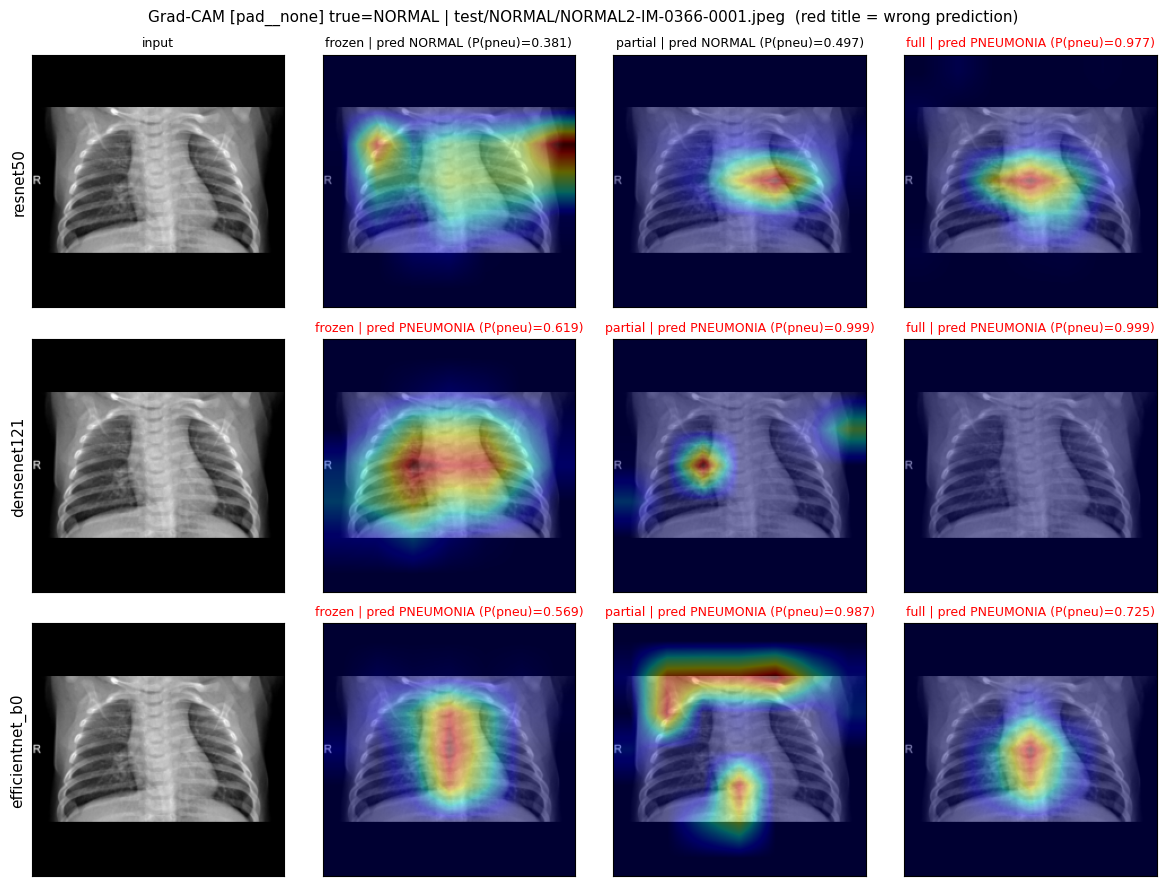

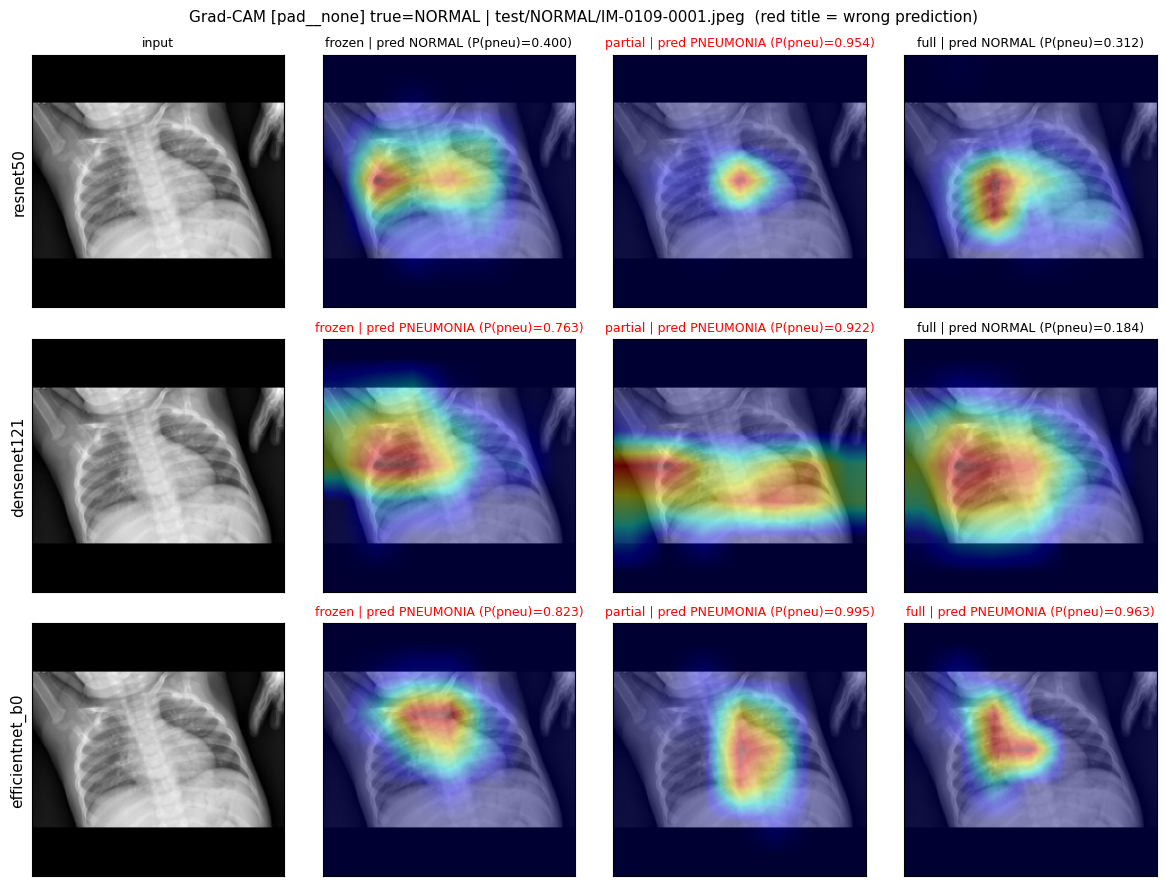

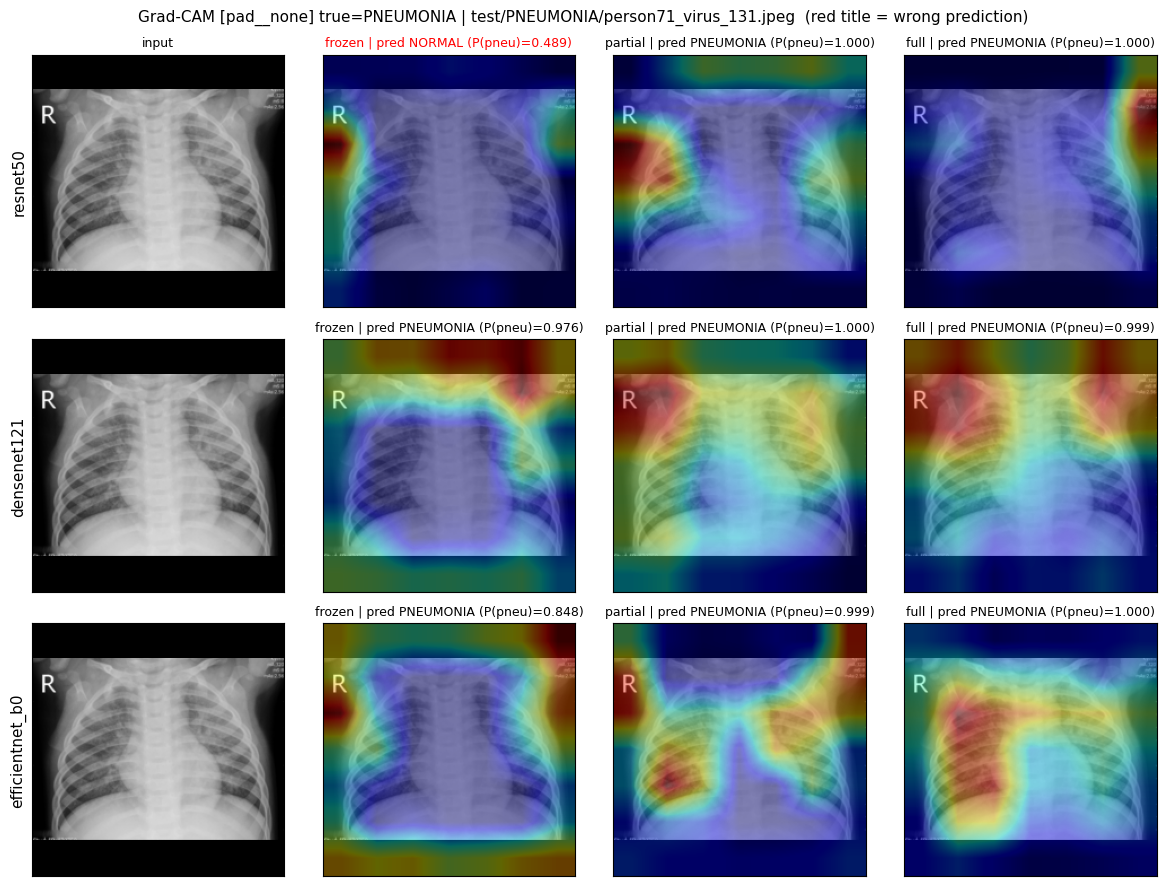

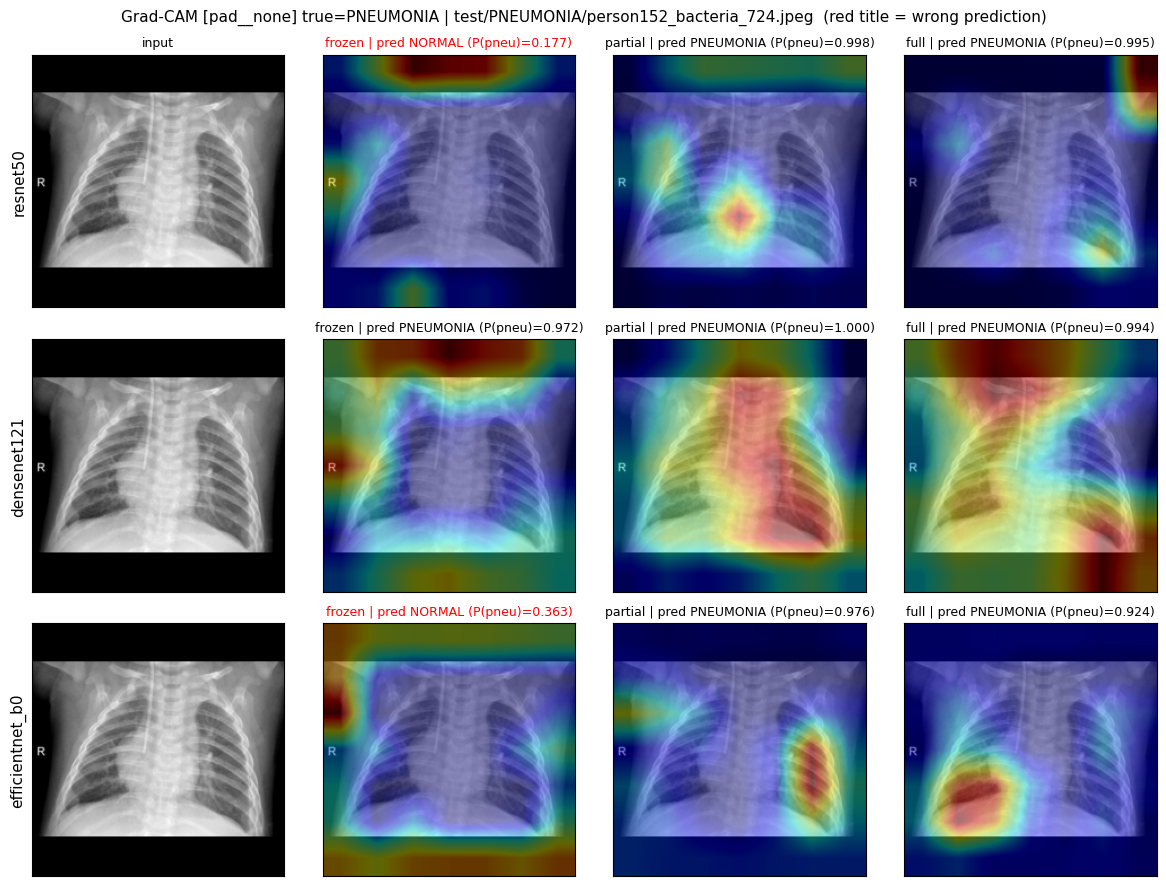

In [48]:
# ---------- 6-4. Grad-CAM: 3모델 x 3모드가 test 이미지의 어디를 보는가 ----------
# 각 모델 마지막 stage 출력(ARCH_SPECS의 last_stage[-1])에서 정답 클래스 logit의 gradient로 Grad-CAM을 계산한다.
# 9개 모델 모두 같은 이미지 / 같은 target class(정답)로 계산해 바로 비교할 수 있게 한다. 이미지는 SEED로 고정해 뽑는다.
# 예측을 다시 하는 셀이지만 이미지 몇 장 x 9 모델 forward/backward라 수 초 안에 끝난다 (6-2의 test 지표 캐시와 무관).
CAM_PER_CLASS = 2   # 클래스별로 뽑을 test 이미지 수


def grad_cam(model: nn.Module, layer: str, x: torch.Tensor, target: torch.Tensor):
    """x: 정규화된 입력 (B,3,H,W), target: (B,) -> (cam (B,H,W) 0~1, PNEUMONIA 확률 (B,))"""
    store = {}

    def hook(_, __, out):
        # frozen backbone은 activation에 grad가 없으므로 끊어서 leaf로 만든다.
        # clone을 넘겨 다음 층의 in-place 연산(DenseNet의 relu(inplace=True))이 저장한 activation을 바꾸지 않게 한다.
        store["act"] = out.detach().requires_grad_(True)
        return store["act"].clone()

    handle = model.get_submodule(layer).register_forward_hook(hook)
    try:
        with torch.enable_grad():
            logits = model(x)
            grad, = torch.autograd.grad(logits.gather(1, target.view(-1, 1)).sum(), store["act"])
    finally:
        handle.remove()
    act = store["act"].detach()
    cam = F.relu((grad.mean((2, 3), keepdim=True) * act).sum(1, keepdim=True))       # 채널 가중치 = gradient의 공간 평균
    cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)[:, 0]
    cam = cam / cam.flatten(1).amax(1).clamp_min(1e-8).view(-1, 1, 1)                 # 이미지마다 최댓값 1로 정규화
    return cam.cpu().numpy(), logits.softmax(1)[:, POS_LABEL].detach().cpu().numpy()


cam_df = pd.concat([test_rows[test_rows["label"] == c].sample(CAM_PER_CLASS, random_state=SEED)
                    for c in range(len(CLASSES))], ignore_index=True)
cam_idx = torch.tensor(cam_df["cache_idx"].to_numpy())
cam_x = GpuTransform(train=False)(device_images(TEST_VARIANT)[cam_idx.to(DEVICE)])
cam_y = torch.tensor(cam_df["label"].to_numpy(), device=DEVICE)

cams, probs = {}, {}
for arch in ARCHS:
    for mode in MODES:
        model, _ = load_best_model(arch, mode, TEST_VARIANT)
        cams[arch, mode], probs[arch, mode] = grad_cam(model, ARCH_SPECS[arch]["last_stage"][-1], cam_x, cam_y)
        del model

for i, r in cam_df.iterrows():
    img = CACHE[TEST_VARIANT][r["cache_idx"]]
    fig, axes = plt.subplots(len(ARCHS), len(MODES) + 1, figsize=(3 * (len(MODES) + 1), 3 * len(ARCHS)))
    for a, arch in enumerate(ARCHS):
        axes[a, 0].imshow(img, cmap="gray")
        axes[a, 0].set_ylabel(arch, fontsize=11)
        for j, mode in enumerate(MODES):
            p = probs[arch, mode][i]
            pred = CLASSES[int(p >= 0.5)]
            ax = axes[a, j + 1]
            ax.imshow(img, cmap="gray")
            ax.imshow(cams[arch, mode][i], cmap="jet", alpha=0.4, vmin=0, vmax=1)
            ax.set_title(f"{mode} | pred {pred} (P(pneu)={p:.3f})", fontsize=9,
                         color="black" if pred == CLASSES[r["label"]] else "red")
    for ax in axes.ravel():
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0, 0].set_title("input", fontsize=9)
    fig.suptitle(f"Grad-CAM [{TEST_VARIANT}] true={CLASSES[r['label']]} | {r['rel_path']}  (red title = wrong prediction)",
                 fontsize=11)
    fig.tight_layout()
    plt.show()
